# End-to-End Sales Forecasting & Demand Intelligence System

### Internship Final Project (Week 3 & Week 4)

**Intern:** Palakurthi Venkatesh Goud

---

## Business Problem

Retail and e-commerce companies rely on accurate demand forecasting to ensure the right products are available at the right time. Overstocking increases inventory holding costs, while understocking results in lost sales, dissatisfied customers, and reduced revenue.

This project develops an intelligent Sales Forecasting & Demand Intelligence System that predicts future demand, detects unusual sales behavior, segments products based on demand characteristics, and presents business insights through an interactive dashboard.

The objective is to support inventory planning, supply chain optimization, and strategic business decision-making using data science and machine learning.

# Project Workflow

This project follows a structured business analytics lifecycle.

1. Business Question
2. Break Down the Problem
3. Form Business Hypotheses
4. Data Collection & Understanding
5. Data Preparation
6. Exploratory Data Analysis
7. Time Series Analysis
8. Forecasting
9. Anomaly Detection
10. Product Demand Segmentation
11. Dashboard Development
12. Business Recommendations
13. Conclusion

# Business Question

The primary objective is to answer the following business questions:

- How much will the company sell over the next three months?
- Which product categories generate the highest revenue?
- Which regions require additional inventory?
- Are there seasonal demand patterns?
- Can abnormal sales spikes or drops be detected automatically?
- How should products be segmented based on demand behavior?
- Which forecasting model performs best for production deployment?

# Business Hypotheses

Before analyzing the data, the following hypotheses are formulated:

H1: Technology products generate the highest revenue.

H2: Monthly sales exhibit strong seasonal patterns.

H3: Holiday periods produce abnormal sales spikes.

H4: The West region consistently records higher sales than other regions.

H5: XGBoost will outperform traditional statistical forecasting models.

H6: Products can be grouped into meaningful demand clusters based on sales behavior.

# Dataset Information

Primary Dataset:
Superstore Sales Dataset

Supplementary Dataset:
Video Game Sales Dataset

Dataset Characteristics

• Four years of retail transaction history

• Daily order-level sales

• Multiple regions

• Multiple product categories

• Customer-level information

• Shipping information

Target Variable

Sales

Business Domain

Retail Analytics

# Success Criteria

The project will be considered successful if it can:

• Forecast future sales accurately

• Detect abnormal sales behavior

• Segment products into meaningful demand groups

• Generate actionable business recommendations

• Present insights through an interactive Streamlit dashboard

• Support inventory planning and supply chain decision-making

# Task 1 – Data Loading, Data Quality Assessment & Business Exploration

## Objective

Before building forecasting models, it is essential to understand the structure, quality, and characteristics of the dataset.

In this section, we:

- Load the dataset
- Understand the business data
- Check data quality
- Engineer time-based features
- Prepare the dataset for forecasting
- Perform an initial business exploration

In [1]:
import matplotlib.pyplot as plt
import os

CHART_DIR = "charts"
os.makedirs(CHART_DIR, exist_ok=True)

_chart_count = 1

_original_show = plt.show

def save_and_show(*args, **kwargs):
    global _chart_count
    plt.savefig(
        os.path.join(CHART_DIR, f"chart_{_chart_count}.png"),
        dpi=300,
        bbox_inches="tight"
    )
    _chart_count += 1
    _original_show(*args, **kwargs)

plt.show = save_and_show

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
df = pd.read_csv("data/train.csv")

df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    dayfirst=True
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    dayfirst=True
)

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [5]:
df.sample(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
9584,9585,CA-2018-132584,2018-08-26,2018-08-27,First Class,HJ-14875,Heather Jas,Home Office,United States,Detroit,Michigan,48234.0,Central,OFF-ST-10000344,Office Supplies,Storage,"Neat Ideas Personal Hanging Folder Files, Black",53.720
1878,1879,CA-2018-118885,2018-12-29,2019-01-02,Standard Class,JG-15160,James Galang,Consumer,United States,Los Angeles,California,90049.0,West,TEC-PH-10002563,Technology,Phones,Adtran 1202752G1,302.376
2790,2791,CA-2015-125514,2015-09-21,2015-09-22,First Class,BM-11650,Brian Moss,Corporate,United States,Omaha,Nebraska,68104.0,Central,OFF-AP-10000358,Office Supplies,Appliances,Fellowes Basic Home/Office Series Surge Protec...,25.960
5639,5640,CA-2015-154893,2015-12-21,2015-12-27,Standard Class,GM-14440,Gary McGarr,Consumer,United States,San Diego,California,92024.0,West,FUR-CH-10000595,Furniture,Chairs,Safco Contoured Stacking Chairs,572.160
407,408,CA-2018-117457,2018-12-08,2018-12-12,Standard Class,KH-16510,Keith Herrera,Consumer,United States,San Francisco,California,94110.0,West,OFF-PA-10003724,Office Supplies,Paper,"Wirebound Message Book, 4 per Page",27.150


In [6]:
print("Rows :",df.shape[0])

print("Columns :",df.shape[1])

Rows : 9800
Columns : 18


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [8]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Row ID,9800.0,4900.5,1.0,2450.75,4900.5,7350.25,9800.0,2829.160653
Order Date,9800,2017-05-01 05:13:51.673469440,2015-01-03 00:00:00,2016-05-24 00:00:00,2017-06-26 00:00:00,2018-05-15 00:00:00,2018-12-30 00:00:00,NaN
Ship Date,9800,2017-05-05 04:17:52.653061120,2015-01-07 00:00:00,2016-05-27 18:00:00,2017-06-29 00:00:00,2018-05-19 00:00:00,2019-01-05 00:00:00,NaN
Postal Code,9789.0,55273.322403,1040.0,23223.0,58103.0,90008.0,99301.0,32041.223413
Sales,9800.0,230.769059,0.444,17.248,54.49,210.605,22638.48,626.651875


In [9]:
df.describe(include="object").T

,count,unique,top,freq
Order ID,9800,4922,CA-2018-100111,14
Ship Mode,9800,4,Standard Class,5859
Customer ID,9800,793,WB-21850,35
Customer Name,9800,793,William Brown,35
Segment,9800,3,Consumer,5101
Country,9800,1,United States,9800
City,9800,529,New York City,891
State,9800,49,California,1946
Region,9800,4,West,3140
Product ID,9800,1861,OFF-PA-10001970,19


In [10]:
missing=df.isnull().sum().sort_values(ascending=False)

missing

Postal Code      11
Row ID            0
Order ID          0
Order Date        0
Ship Mode         0
Ship Date         0
Customer Name     0
Segment           0
Country           0
Customer ID       0
City              0
State             0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [11]:
missing_percentage=(df.isnull().mean()*100).sort_values(ascending=False)

missing_percentage

Postal Code      0.112245
Row ID           0.000000
Order ID         0.000000
Order Date       0.000000
Ship Mode        0.000000
Ship Date        0.000000
Customer Name    0.000000
Segment          0.000000
Country          0.000000
Customer ID      0.000000
City             0.000000
State            0.000000
Region           0.000000
Product ID       0.000000
Category         0.000000
Sub-Category     0.000000
Product Name     0.000000
Sales            0.000000
dtype: float64

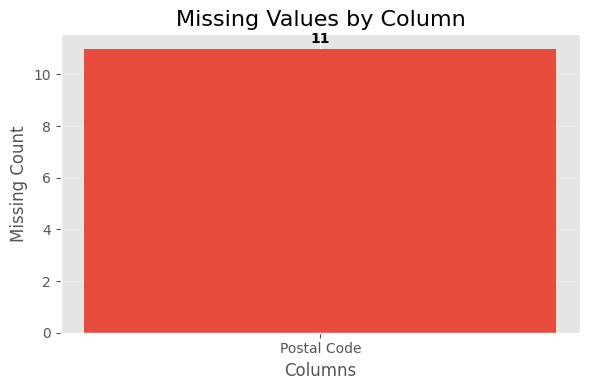

In [12]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(6,4))

plt.bar(
    missing.index,
    missing.values,
    color="#E74C3C"
)

plt.title("Missing Values by Column", fontsize=16)
plt.ylabel("Missing Count")
plt.xlabel("Columns")

for i, v in enumerate(missing.values):
    plt.text(i, v+0.2, str(v), ha='center', fontweight='bold')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
duplicates=df.duplicated().sum()

print("Duplicate Records :",duplicates)

Duplicate Records : 0


In [14]:
df=df.drop_duplicates()

In [15]:
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
dtype: object

In [16]:
numeric_columns=df.select_dtypes(include="number").columns

categorical_columns=df.select_dtypes(include="object").columns

datetime_columns=df.select_dtypes(include="datetime").columns

print("Numeric Columns")

print(numeric_columns)

print()

print("Categorical Columns")

print(categorical_columns)

print()

print("Datetime Columns")

print(datetime_columns)

Numeric Columns
Index(['Row ID', 'Postal Code', 'Sales'], dtype='object')

Categorical Columns
Index(['Order ID', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment',
       'Country', 'City', 'State', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name'],
      dtype='object')

Datetime Columns
Index(['Order Date', 'Ship Date'], dtype='object')


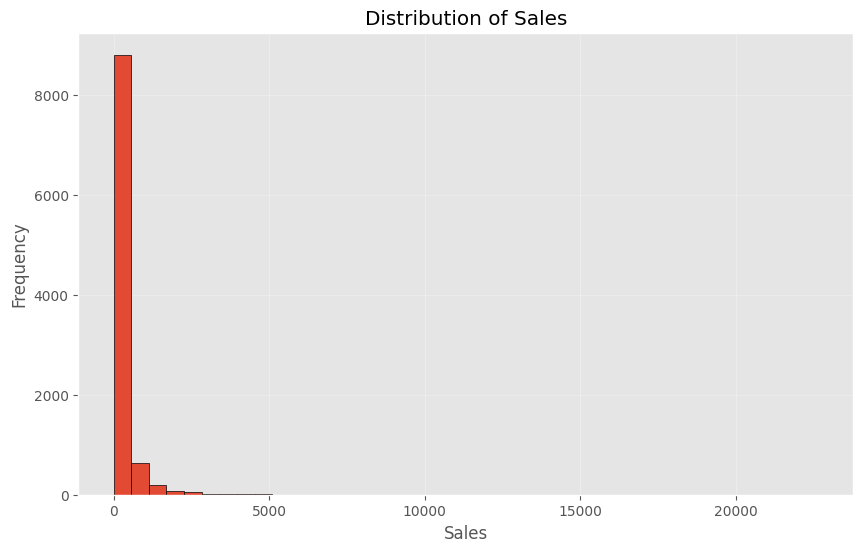

In [17]:
plt.figure(figsize=(10,6))

plt.hist(df["Sales"], bins=40, edgecolor="black")

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

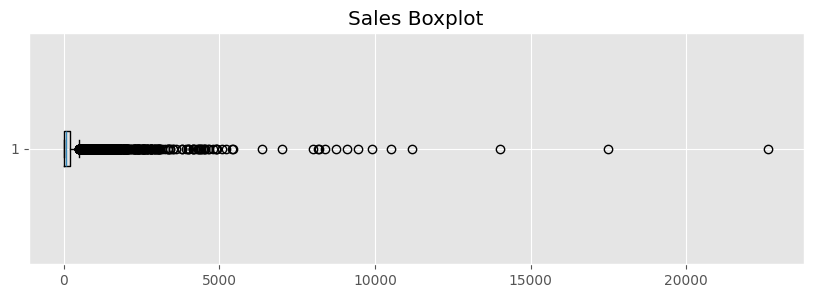

In [18]:
plt.figure(figsize=(10,3))

plt.boxplot(df["Sales"], vert=False)

plt.title("Sales Boxplot")

plt.show()

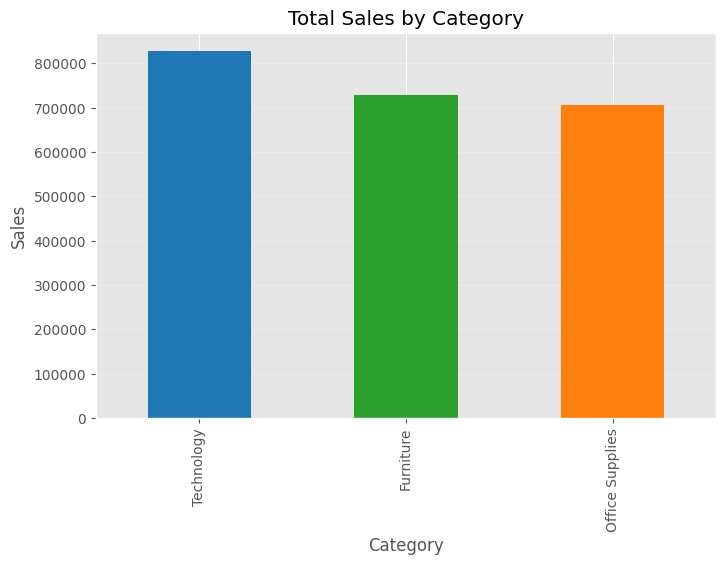

In [19]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

category_sales.plot(
    kind="bar",
    color=["#1f77b4","#2ca02c","#ff7f0e"]
)

plt.title("Total Sales by Category")
plt.ylabel("Sales")
plt.xlabel("Category")

plt.grid(axis="y", alpha=0.3)

plt.show()

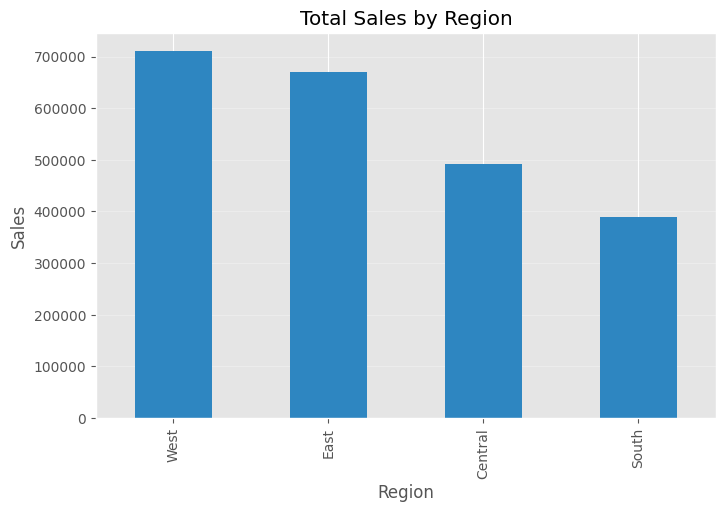

In [20]:
region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

region_sales.plot(
    kind="bar",
    color="#2E86C1"
)

plt.title("Total Sales by Region")
plt.ylabel("Sales")

plt.grid(axis="y", alpha=0.3)

plt.show()

## Business Insights from Exploratory Data Analysis

The initial exploratory analysis provides valuable insights into the overall sales behavior and business performance of the organization.

The sales distribution is highly right-skewed, indicating that the majority of transactions involve relatively small purchase amounts, while a limited number of high-value orders contribute significantly to total revenue. The boxplot further confirms the presence of these high-value transactions. Since these represent legitimate business activities rather than data errors, they will be retained for forecasting.

Category-wise analysis shows that **Technology** is the highest revenue-generating product category, followed by **Furniture** and **Office Supplies**, highlighting Technology as the primary business driver.

Regional analysis reveals that the **West** region generates the highest sales, followed by the **East**, while the **South** region records the lowest revenue. These findings suggest opportunities for improved regional inventory planning, targeted marketing strategies, and resource allocation.

Overall, the dataset exhibits excellent data quality with negligible missing values and no duplicate records. The insights obtained during this analysis establish a strong foundation for feature engineering, time-series analysis, and the development of an accurate sales forecasting model in the subsequent stages of the project.

# Time Series Analysis

## Objective

Sales forecasting relies heavily on understanding historical sales trends over time. This analysis explores how sales have changed across different time periods, identifies seasonal patterns, growth trends, and recurring business cycles.

The insights obtained from this section will guide feature engineering and help improve forecasting model performance.

In [21]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.strftime("%b")
df["Quarter"] = df["Order Date"].dt.quarter
df["Day"] = df["Order Date"].dt.day
df["Day Name"] = df["Order Date"].dt.day_name()
df["Weekday"] = df["Order Date"].dt.weekday

In [22]:
df[["Order Date","Year","Month","Month Name","Quarter","Day","Day Name"]].head()

,Order Date,Year,Month,Month Name,Quarter,Day,Day Name
0,2017-11-08,2017,11,Nov,4,8,Wednesday
1,2017-11-08,2017,11,Nov,4,8,Wednesday
2,2017-06-12,2017,6,Jun,2,12,Monday
3,2016-10-11,2016,10,Oct,4,11,Tuesday
4,2016-10-11,2016,10,Oct,4,11,Tuesday


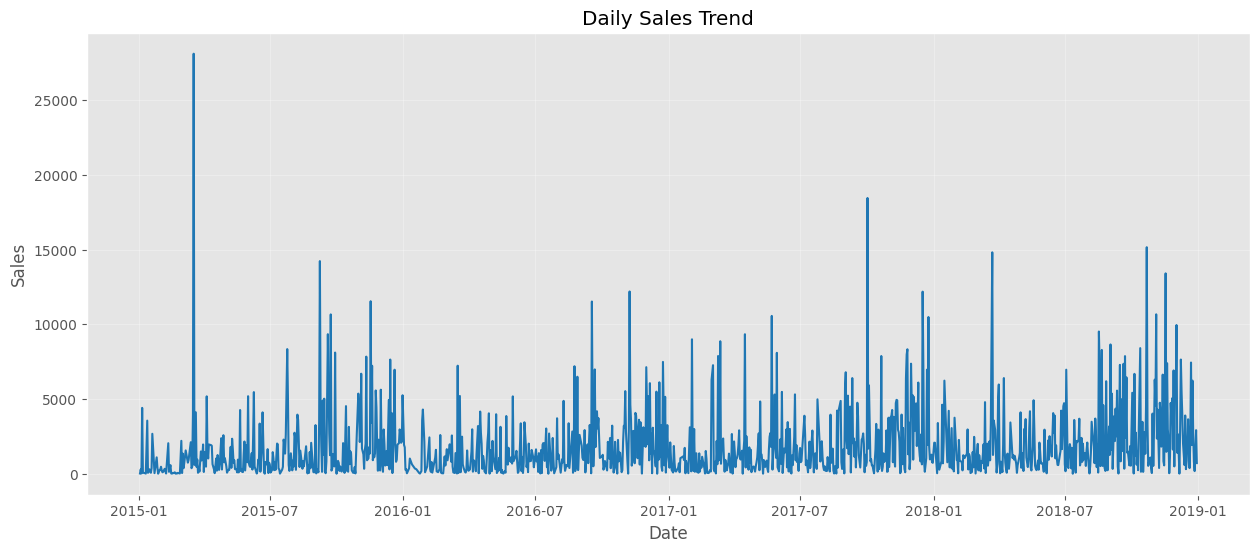

In [23]:
daily_sales = (
    df.groupby("Order Date")["Sales"]
      .sum()
      .sort_index()
)

plt.figure(figsize=(15,6))

plt.plot(
    daily_sales.index,
    daily_sales.values,
    linewidth=1.5,
    color="#1f77b4"
)

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.grid(alpha=0.3)

plt.show()

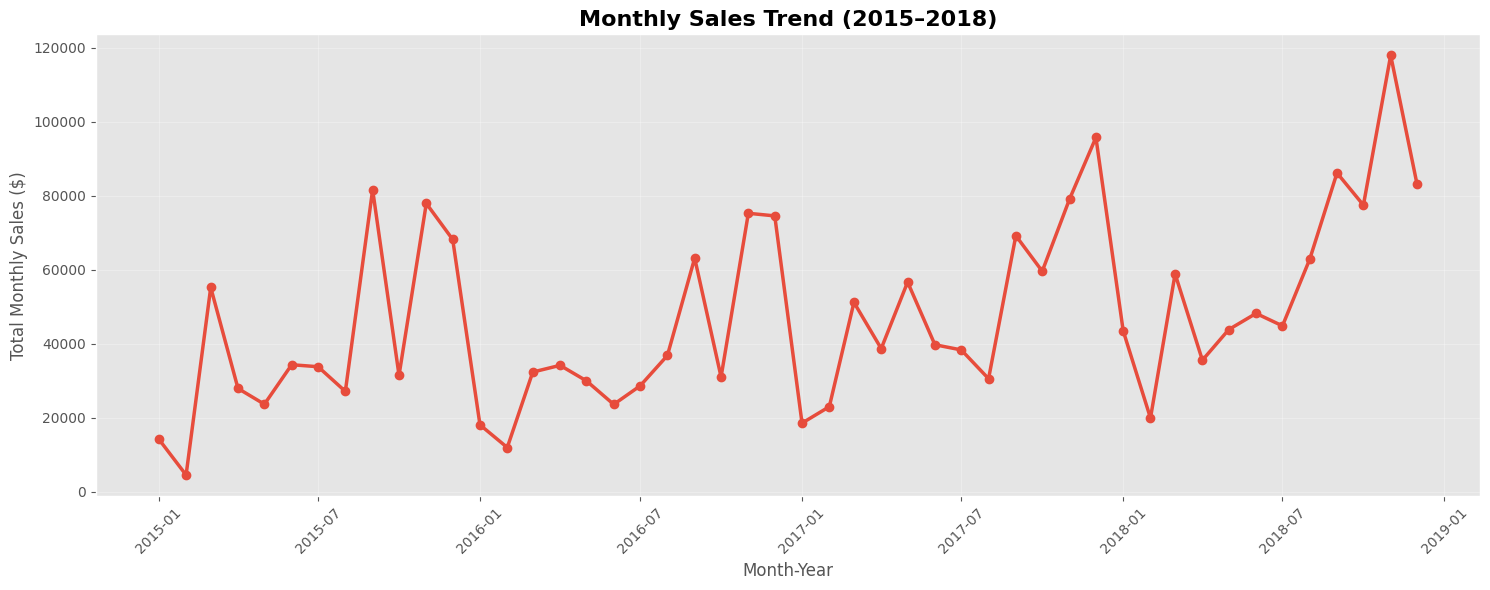

In [24]:
monthly_sales = (
    df.groupby(["Year", "Month"])["Sales"]
      .sum()
      .reset_index()
)

monthly_sales["Date"] = pd.to_datetime(
    monthly_sales[["Year", "Month"]].assign(day=1)
)

plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales["Date"],
    monthly_sales["Sales"],
    marker="o",
    markersize=6,
    linewidth=2.5,
    color="#E74C3C"
)

plt.title("Monthly Sales Trend (2015–2018)", fontsize=16, fontweight="bold")
plt.xlabel("Month-Year")
plt.ylabel("Total Monthly Sales ($)")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.tight_layout()

plt.show()

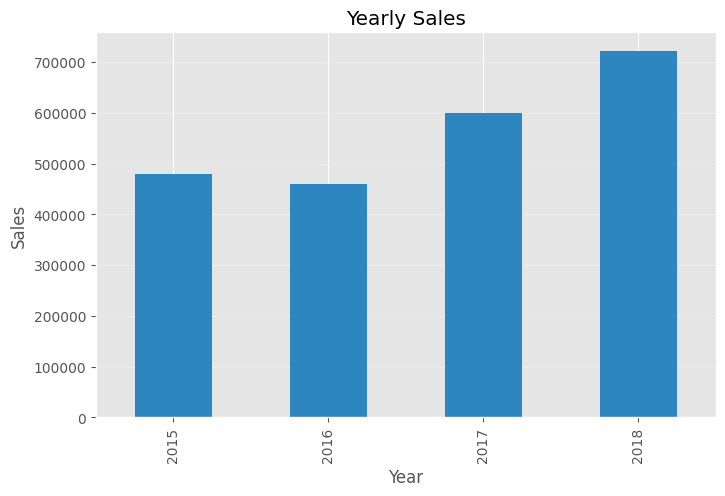

In [25]:
year_sales = (
    df.groupby("Year")["Sales"]
      .sum()
)

plt.figure(figsize=(8,5))

year_sales.plot(
    kind="bar",
    color="#2E86C1"
)

plt.title("Yearly Sales")
plt.ylabel("Sales")

plt.grid(axis="y", alpha=0.3)

plt.show()

## Time Series Insights

The historical sales analysis indicates noticeable fluctuations across different time periods, reflecting the dynamic nature of retail demand. Daily sales exhibit significant variability, while monthly and yearly trends provide a clearer understanding of long-term business performance.

These temporal patterns suggest the presence of seasonality and changing customer demand over time, making historical sales behavior a valuable predictor for future sales forecasting.

The extracted date features (Year, Month, Quarter, and Day) will serve as important inputs during feature engineering and machine learning model development.

## Daily Sales Trend

The daily sales trend illustrates significant fluctuations in customer purchases throughout the four-year period. While most days record moderate sales volumes, several days exhibit exceptionally high sales spikes.

These peaks may correspond to seasonal demand, promotional campaigns, large corporate purchases, or holiday shopping periods. Such variability indicates that daily sales are highly dynamic and influenced by multiple business factors.

**Business Insight:**
Daily sales data captures short-term demand patterns and provides valuable information for inventory planning, workforce scheduling, and anomaly detection. It also highlights the need for forecasting models that can handle sudden fluctuations in demand.

## Monthly Sales Trend

Monthly aggregation reveals a much clearer business trend compared to daily sales. Although monthly sales fluctuate over time, an overall upward trajectory is visible from 2015 to 2018.

Several months record substantially higher sales than others, suggesting recurring seasonal demand and periodic business growth. The final year (2018) consistently demonstrates stronger monthly performance than previous years.

**Business Insight:**
Monthly sales trends are highly valuable for demand forecasting, budgeting, inventory management, and strategic planning. They provide a balanced view by reducing daily noise while preserving important seasonal patterns.

## Yearly Sales Trend

Yearly sales analysis shows continuous business growth across the available time period. Total annual sales increased considerably after 2016, with 2018 recording the highest overall revenue.

The steady increase suggests expanding customer demand, improved market performance, or successful business strategies implemented during later years.

**Business Insight:**
The positive long-term growth trend indicates a healthy business trajectory. Historical yearly performance provides strong evidence that time-related features should play a significant role in forecasting future sales and estimating long-term demand.

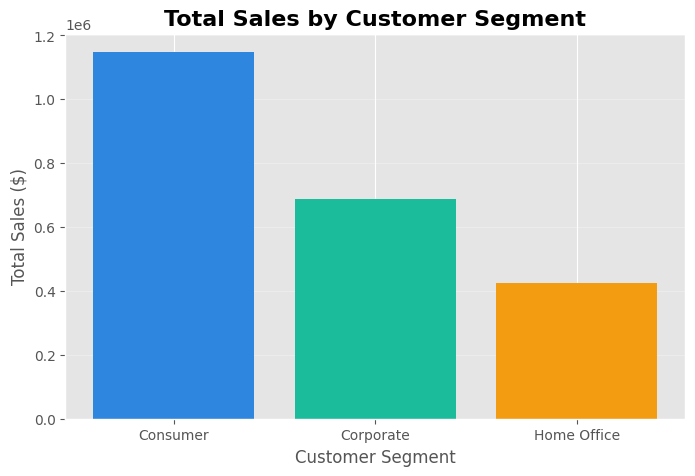

In [26]:
segment_sales = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
plt.bar(segment_sales.index, segment_sales.values,
        color=["#2E86DE","#1ABC9C","#F39C12"])

plt.title("Total Sales by Customer Segment", fontsize=16, weight="bold")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales ($)")
plt.grid(axis="y", alpha=0.3)

plt.show()

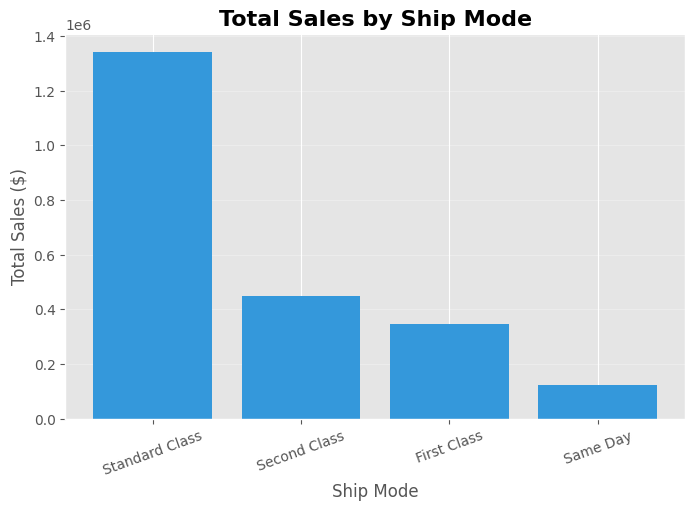

In [27]:
ship_sales = df.groupby("Ship Mode")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
plt.bar(ship_sales.index, ship_sales.values,
        color="#3498DB")

plt.title("Total Sales by Ship Mode", fontsize=16, weight="bold")
plt.xlabel("Ship Mode")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

plt.show()

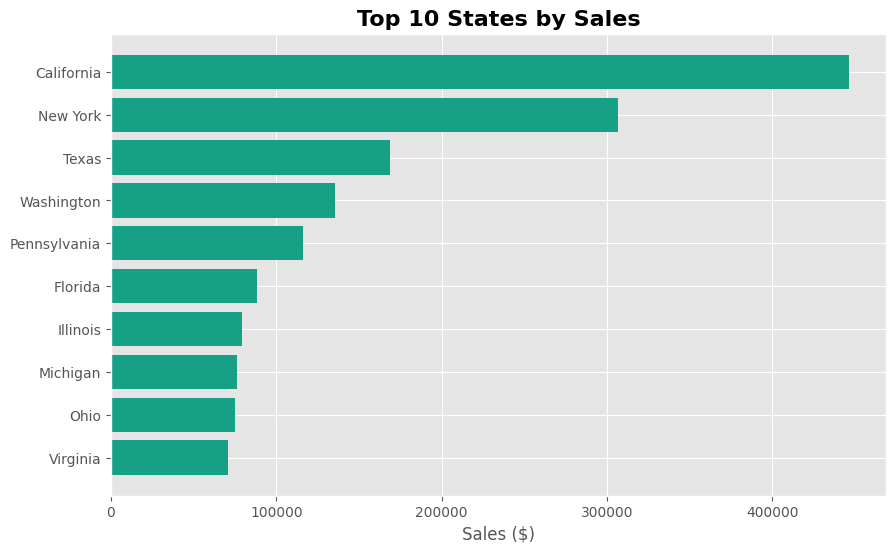

In [28]:
top_states = (
    df.groupby("State")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))
plt.barh(top_states.index, top_states.values,
         color="#16A085")

plt.title("Top 10 States by Sales", fontsize=16, weight="bold")
plt.xlabel("Sales ($)")
plt.gca().invert_yaxis()

plt.show()

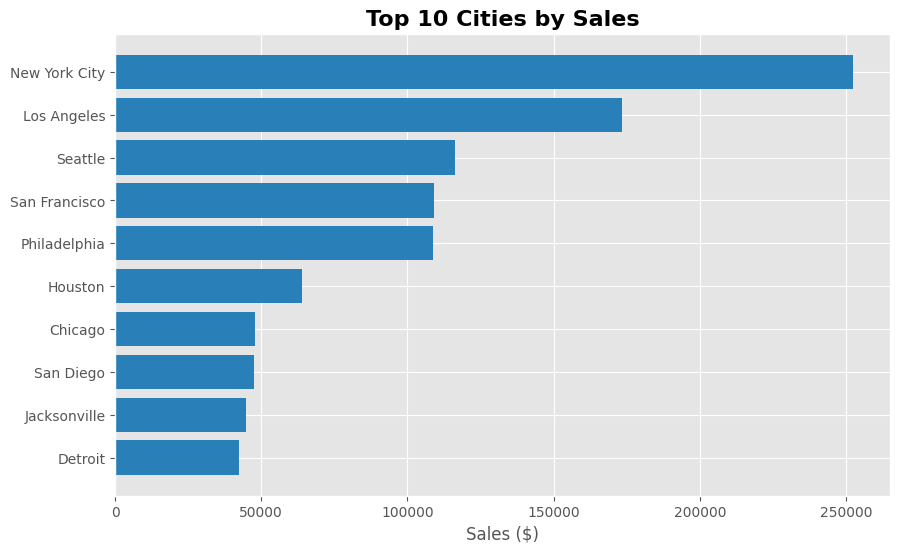

In [29]:
top_cities = (
    df.groupby("City")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))
plt.barh(top_cities.index, top_cities.values,
         color="#2980B9")

plt.title("Top 10 Cities by Sales", fontsize=16, weight="bold")
plt.xlabel("Sales ($)")
plt.gca().invert_yaxis()

plt.show()

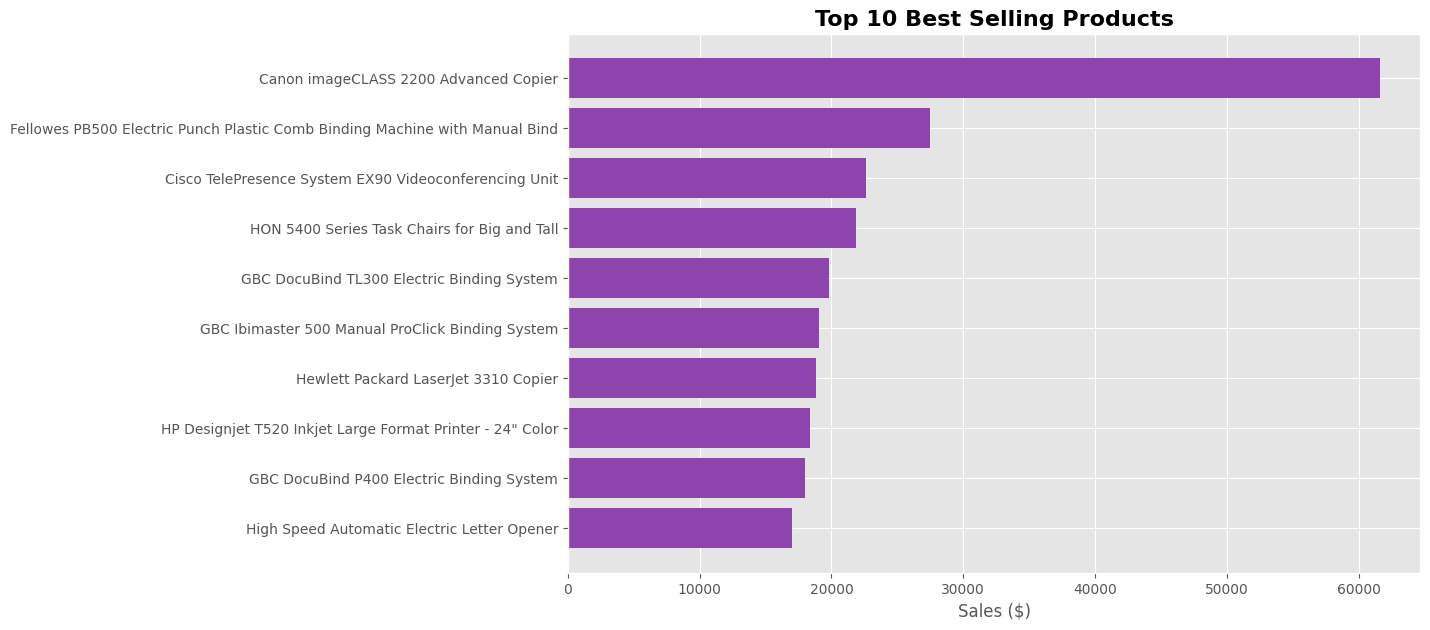

In [30]:
top_products = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(11,7))
plt.barh(top_products.index, top_products.values,
         color="#8E44AD")

plt.title("Top 10 Best Selling Products", fontsize=16, weight="bold")
plt.xlabel("Sales ($)")
plt.gca().invert_yaxis()

plt.show()

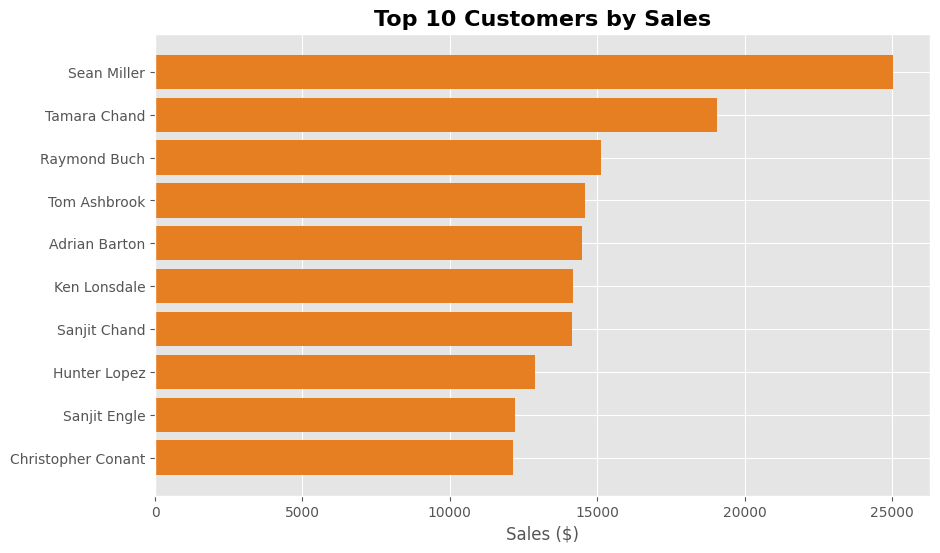

In [31]:
top_customers = (
    df.groupby("Customer Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))
plt.barh(top_customers.index, top_customers.values,
         color="#E67E22")

plt.title("Top 10 Customers by Sales", fontsize=16, weight="bold")
plt.xlabel("Sales ($)")
plt.gca().invert_yaxis()

plt.show()

# Business Insights: Customer, Geography & Product Analysis

## Objective

Understand which customer groups, shipping methods, regions, products, and customers contribute the most revenue. These insights help businesses identify high-value markets, optimize logistics, improve customer retention, and maximize sales performance.

### Customer Segment Analysis

The Consumer segment generated the highest revenue, contributing approximately **$1.15 million**, making it the company's primary customer base.

Corporate customers ranked second with nearly **$690K** in sales, while the Home Office segment generated around **$425K**.

**Business Insight**

- Consumer customers are the largest revenue drivers.
- Corporate customers represent strong B2B opportunities.
- Home Office customers contribute the least and may require targeted marketing campaigns to increase sales.

### Shipping Mode Analysis

Standard Class shipping accounts for the highest sales, contributing nearly **$1.35 million**.

Second Class and First Class contribute significantly less, while Same Day delivery represents only a small portion of total sales.

**Business Insight**

- Most customers prioritize economical shipping over speed.
- Logistics optimization should primarily focus on Standard Class operations.
- Premium shipping services can be promoted through special offers to increase adoption.

### Geographic Sales Analysis

California generated the highest sales among all states, followed by New York and Texas.

At the city level, New York City contributed the highest revenue, followed by Los Angeles and Seattle.

**Business Insight**

- California and New York are the strongest revenue markets.
- These locations should remain high-priority regions for inventory planning and marketing investments.
- Lower-performing states represent potential growth opportunities through localized campaigns.

### Product Performance Analysis

The Canon imageCLASS 2200 Advanced Copier is the highest revenue-generating product, significantly outperforming other products.

Several office equipment and technology products dominate the Top 10 list.

**Business Insight**

- High-value technology products contribute a large portion of revenue.
- These products should receive priority inventory allocation.
- Product bundles and extended warranty plans could further increase profitability.

### Customer Value Analysis

Sean Miller is the company's highest-value customer, followed by Tamara Chand and Raymond Buch.

The Top 10 customers contribute a substantial portion of overall revenue.

**Business Insight**

- High-value customers should be included in loyalty and retention programs.
- Personalized offers can improve customer lifetime value.
- Losing these customers would significantly impact total revenue.

## Key Findings

- Consumer customers generate the highest revenue.
- Standard Class is the preferred shipping method.
- California and New York dominate total sales.
- Technology products contribute the highest revenue.
- A small group of customers contributes a disproportionately high share of sales.

These findings provide valuable business intelligence that can guide marketing strategy, inventory management, logistics planning, and customer retention initiatives.

# Sales Forecasting Dataset Preparation

## Objective

Prepare the sales dataset for forecasting by aggregating daily sales, checking time continuity, and creating a clean time-series dataset suitable for machine learning models.

This step transforms transactional sales data into a structured chronological dataset where each observation represents total sales for a single day.

In [32]:
daily_sales = (
    df.groupby("Order Date")["Sales"]
      .sum()
      .reset_index()
)

daily_sales = daily_sales.sort_values("Order Date")

daily_sales.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [33]:
print("Total Days :", len(daily_sales))
print()
print(daily_sales.head())
print()
print(daily_sales.tail())

Total Days : 1230

  Order Date     Sales
0 2015-01-03    16.448
1 2015-01-04   288.060
2 2015-01-05    19.536
3 2015-01-06  4407.100
4 2015-01-07    87.158

     Order Date      Sales
1225 2018-12-26   814.5940
1226 2018-12-27   177.6360
1227 2018-12-28  1657.3508
1228 2018-12-29  2915.5340
1229 2018-12-30   713.7900


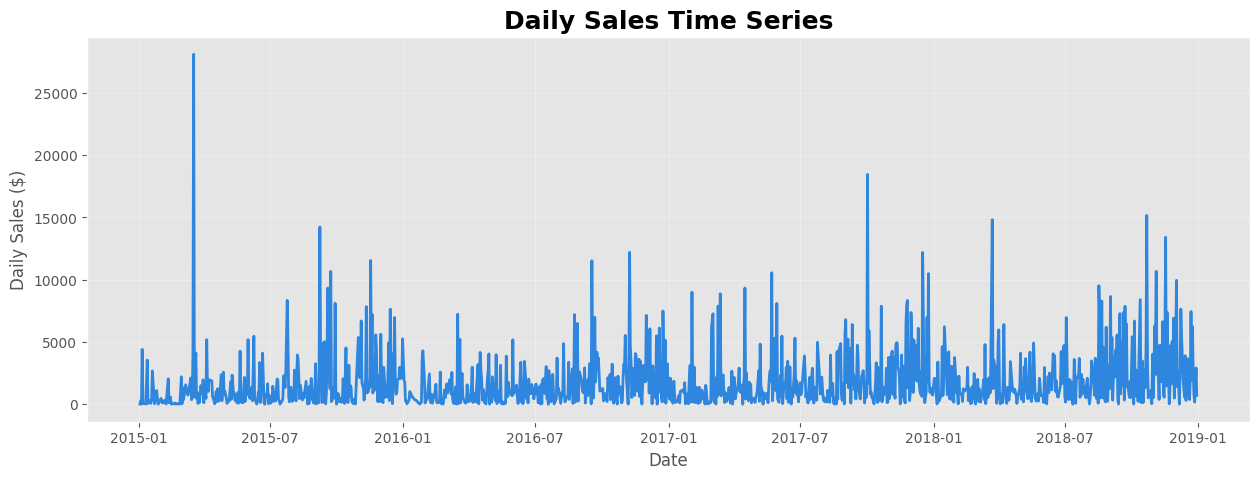

In [34]:
plt.figure(figsize=(15,5))

plt.plot(
    daily_sales["Order Date"],
    daily_sales["Sales"],
    color="#2E86DE",
    linewidth=2
)

plt.title("Daily Sales Time Series", fontsize=18, weight="bold")
plt.xlabel("Date")
plt.ylabel("Daily Sales ($)")
plt.grid(alpha=0.3)

plt.show()

In [35]:
daily_sales.describe()

,Order Date,Sales
count,1230,1230.000000
mean,2017-01-21 12:17:33.658536704,1838.647791
min,2015-01-03 00:00:00,2.025000
25%,2016-01-09 06:00:00,378.519000
50%,2017-02-04 12:00:00,1058.397000
75%,2018-01-20 18:00:00,2382.217000
max,2018-12-30 00:00:00,28106.716000
std,NaN,2295.418267


In [36]:
daily_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1230 entries, 0 to 1229
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Order Date  1230 non-null   datetime64[ns]
 1   Sales       1230 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 19.3 KB


## Observations

The transactional dataset has now been transformed into a chronological daily sales dataset.

Each row now represents one day instead of individual customer purchases.

This structure is required for forecasting algorithms such as Prophet, ARIMA, XGBoost, and LSTM.

The time series appears continuous over four years, making it suitable for predictive modeling.

# Feature Engineering for Sales Forecasting

## Objective

Create time-based and lag-based features that help machine learning models learn sales patterns, seasonality, trends, and historical dependencies.

These engineered features improve forecasting accuracy and allow the model to capture weekly, monthly, and yearly purchasing behavior.

In [37]:
forecast_df = daily_sales.copy()

forecast_df["Year"] = forecast_df["Order Date"].dt.year
forecast_df["Month"] = forecast_df["Order Date"].dt.month
forecast_df["Quarter"] = forecast_df["Order Date"].dt.quarter
forecast_df["Week"] = forecast_df["Order Date"].dt.isocalendar().week.astype(int)
forecast_df["Day"] = forecast_df["Order Date"].dt.day
forecast_df["DayOfWeek"] = forecast_df["Order Date"].dt.dayofweek
forecast_df["DayOfYear"] = forecast_df["Order Date"].dt.dayofyear
forecast_df["IsWeekend"] = (forecast_df["DayOfWeek"] >= 5).astype(int)

forecast_df.head()

,Order Date,Sales,Year,Month,Quarter,Week,Day,DayOfWeek,DayOfYear,IsWeekend
0,2015-01-03,16.448,2015,1,1,1,3,5,3,1
1,2015-01-04,288.060,2015,1,1,1,4,6,4,1
2,2015-01-05,19.536,2015,1,1,2,5,0,5,0
3,2015-01-06,4407.100,2015,1,1,2,6,1,6,0
4,2015-01-07,87.158,2015,1,1,2,7,2,7,0


In [38]:
forecast_df["Lag_1"] = forecast_df["Sales"].shift(1)
forecast_df["Lag_7"] = forecast_df["Sales"].shift(7)
forecast_df["Lag_30"] = forecast_df["Sales"].shift(30)

forecast_df.head(35)

,Order Date,Sales,Year,Month,Quarter,Week,Day,DayOfWeek,DayOfYear,IsWeekend,Lag_1,Lag_7,Lag_30
0,2015-01-03,16.448,2015,1,1,1,3,5,3,1,NaN,NaN,NaN
1,2015-01-04,288.060,2015,1,1,1,4,6,4,1,16.448,NaN,NaN
2,2015-01-05,19.536,2015,1,1,2,5,0,5,0,288.060,NaN,NaN
3,2015-01-06,4407.100,2015,1,1,2,6,1,6,0,19.536,NaN,NaN
4,2015-01-07,87.158,2015,1,1,2,7,2,7,0,4407.100,NaN,NaN
5,2015-01-09,40.544,2015,1,1,2,9,4,9,0,87.158,NaN,NaN
6,2015-01-10,54.830,2015,1,1,2,10,5,10,1,40.544,NaN,NaN
7,2015-01-11,9.940,2015,1,1,2,11,6,11,1,54.830,16.448,NaN
8,2015-01-13,3553.795,2015,1,1,3,13,1,13,0,9.940,288.060,NaN
9,2015-01-14,61.960,2015,1,1,3,14,2,14,0,3553.795,19.536,NaN


In [39]:
forecast_df["Rolling_7"] = forecast_df["Sales"].rolling(7).mean()
forecast_df["Rolling_30"] = forecast_df["Sales"].rolling(30).mean()

forecast_df.head(35)

,Order Date,Sales,Year,Month,Quarter,Week,Day,DayOfWeek,DayOfYear,IsWeekend,Lag_1,Lag_7,Lag_30,Rolling_7,Rolling_30
0,2015-01-03,16.448,2015,1,1,1,3,5,3,1,NaN,NaN,NaN,NaN,NaN
1,2015-01-04,288.060,2015,1,1,1,4,6,4,1,16.448,NaN,NaN,NaN,NaN
2,2015-01-05,19.536,2015,1,1,2,5,0,5,0,288.060,NaN,NaN,NaN,NaN
3,2015-01-06,4407.100,2015,1,1,2,6,1,6,0,19.536,NaN,NaN,NaN,NaN
4,2015-01-07,87.158,2015,1,1,2,7,2,7,0,4407.100,NaN,NaN,NaN,NaN
5,2015-01-09,40.544,2015,1,1,2,9,4,9,0,87.158,NaN,NaN,NaN,NaN
6,2015-01-10,54.830,2015,1,1,2,10,5,10,1,40.544,NaN,NaN,701.953714,NaN
7,2015-01-11,9.940,2015,1,1,2,11,6,11,1,54.830,16.448,NaN,701.024000,NaN
8,2015-01-13,3553.795,2015,1,1,3,13,1,13,0,9.940,288.060,NaN,1167.557571,NaN
9,2015-01-14,61.960,2015,1,1,3,14,2,14,0,3553.795,19.536,NaN,1173.618143,NaN


In [40]:
forecast_df = forecast_df.dropna().reset_index(drop=True)

forecast_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Order Date  1200 non-null   datetime64[ns]
 1   Sales       1200 non-null   float64       
 2   Year        1200 non-null   int32         
 3   Month       1200 non-null   int32         
 4   Quarter     1200 non-null   int32         
 5   Week        1200 non-null   int64         
 6   Day         1200 non-null   int32         
 7   DayOfWeek   1200 non-null   int32         
 8   DayOfYear   1200 non-null   int32         
 9   IsWeekend   1200 non-null   int64         
 10  Lag_1       1200 non-null   float64       
 11  Lag_7       1200 non-null   float64       
 12  Lag_30      1200 non-null   float64       
 13  Rolling_7   1200 non-null   float64       
 14  Rolling_30  1200 non-null   float64       
dtypes: datetime64[ns](1), float64(6), int32(6), int64(2)
memory usage: 112.6

In [41]:
forecast_df.head()

,Order Date,Sales,Year,Month,Quarter,Week,Day,DayOfWeek,DayOfYear,IsWeekend,Lag_1,Lag_7,Lag_30,Rolling_7,Rolling_30
0,2015-02-14,576.726,2015,2,1,7,14,5,45,1,129.568,97.112,16.448,487.067143,612.546233
1,2015-02-15,21.360,2015,2,1,7,15,6,46,1,576.726,134.384,288.060,470.920857,603.656233
2,2015-02-16,9.040,2015,2,1,8,16,0,47,0,21.360,330.512,19.536,424.996286,603.306367
3,2015-02-17,54.208,2015,2,1,8,17,1,48,0,9.040,180.320,4407.100,406.980286,458.209967
4,2015-02-18,37.784,2015,2,1,8,18,2,49,0,54.208,14.560,87.158,410.298000,456.564167


# Machine Learning Model Development

## Objective

Train machine learning models to forecast future daily sales using engineered temporal and historical features.

The models will learn seasonal trends, weekly patterns, long-term growth, and historical sales behavior to generate accurate future sales predictions.

Model performance will be evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

The best-performing model will later be used for deployment in the interactive forecasting dashboard.

In [42]:
features = [
    "Year",
    "Month",
    "Quarter",
    "Week",
    "Day",
    "DayOfWeek",
    "DayOfYear",
    "IsWeekend",
    "Lag_1",
    "Lag_7",
    "Lag_30",
    "Rolling_7",
    "Rolling_30"
]

split = int(len(forecast_df) * 0.80)

train = forecast_df.iloc[:split]
test = forecast_df.iloc[split:]

X_train = train[features]
X_test = test[features]

y_train = train["Sales"]
y_test = test["Sales"]

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 960
Testing Samples: 240


In [43]:
print(X_train.head())

   Year  Month  Quarter  Week  Day  DayOfWeek  DayOfYear  IsWeekend    Lag_1  \
0  2015      2        1     7   14          5         45          1  129.568   
1  2015      2        1     7   15          6         46          1  576.726   
2  2015      2        1     8   16          0         47          0   21.360   
3  2015      2        1     8   17          1         48          0    9.040   
4  2015      2        1     8   18          2         49          0   54.208   

     Lag_7    Lag_30   Rolling_7  Rolling_30  
0   97.112    16.448  487.067143  612.546233  
1  134.384   288.060  470.920857  603.656233  
2  330.512    19.536  424.996286  603.306367  
3  180.320  4407.100  406.980286  458.209967  
4   14.560    87.158  410.298000  456.564167  


In [44]:
split = int(len(df) * 0.80)

train = df.iloc[:split]
test = df.iloc[split:]

X_train = train.drop(columns=["Order Date", "Sales"])
y_train = train["Sales"]

X_test = test.drop(columns=["Order Date", "Sales"])
y_test = test["Sales"]

print("Training Samples :", len(train))
print("Testing Samples  :", len(test))

Training Samples : 7840
Testing Samples  : 1960


In [45]:
print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

Training Samples : 7840
Testing Samples  : 1960


In [46]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

In [47]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

ValueError: could not convert string to float: 'CA-2017-152156'

In [ ]:
mae = mean_absolute_error(y_test, lr_pred)

rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

r2 = r2_score(y_test, lr_pred)

print("Linear Regression Results")
print("-------------------------")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

Linear Regression Results
-------------------------
MAE  : 1609.79
RMSE : 2179.48
R²   : 0.2141


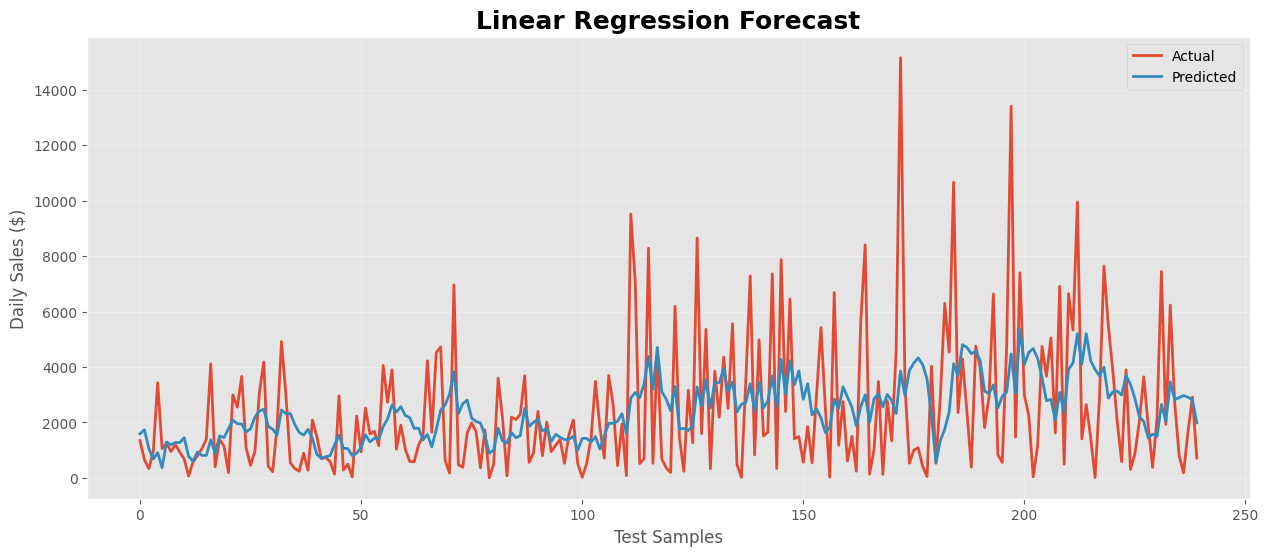

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(
    y_test.values,
    label="Actual",
    linewidth=2
)

plt.plot(
    lr_pred,
    label="Predicted",
    linewidth=2
)

plt.title("Linear Regression Forecast", fontsize=18, weight="bold")
plt.xlabel("Test Samples")
plt.ylabel("Daily Sales ($)")
plt.legend()

plt.grid(alpha=0.3)

plt.show()

# Linear Regression Results

## Objective

Linear Regression was used as the baseline forecasting model.

It establishes a performance benchmark before evaluating more advanced machine learning algorithms.

## Results

- MAE: 1609.79
- RMSE: 2179.48
- R² Score: 0.2141

## Interpretation

The model successfully captured the overall sales trend but struggled to predict sudden fluctuations and high-sales spikes.

This is expected because Linear Regression assumes a simple linear relationship between the features and target variable.

Retail sales are influenced by seasonality, promotions, holidays, customer behavior, and other complex non-linear factors that cannot be fully represented using a linear model.

Therefore, Linear Regression serves as a baseline model rather than the final forecasting solution.

In [ ]:
print(X_train.columns)

Index(['Row ID', 'Order ID', 'Ship Date', 'Ship Mode', 'Customer ID',
       'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name',
       'Year', 'Month', 'Month Name', 'Quarter', 'Day', 'Day Name', 'Weekday'],
      dtype='object')


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, rf_pred)
rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("-"*30)
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

Random Forest Results
------------------------------
MAE  : 1714.90
RMSE : 2292.55
R²   : 0.1304


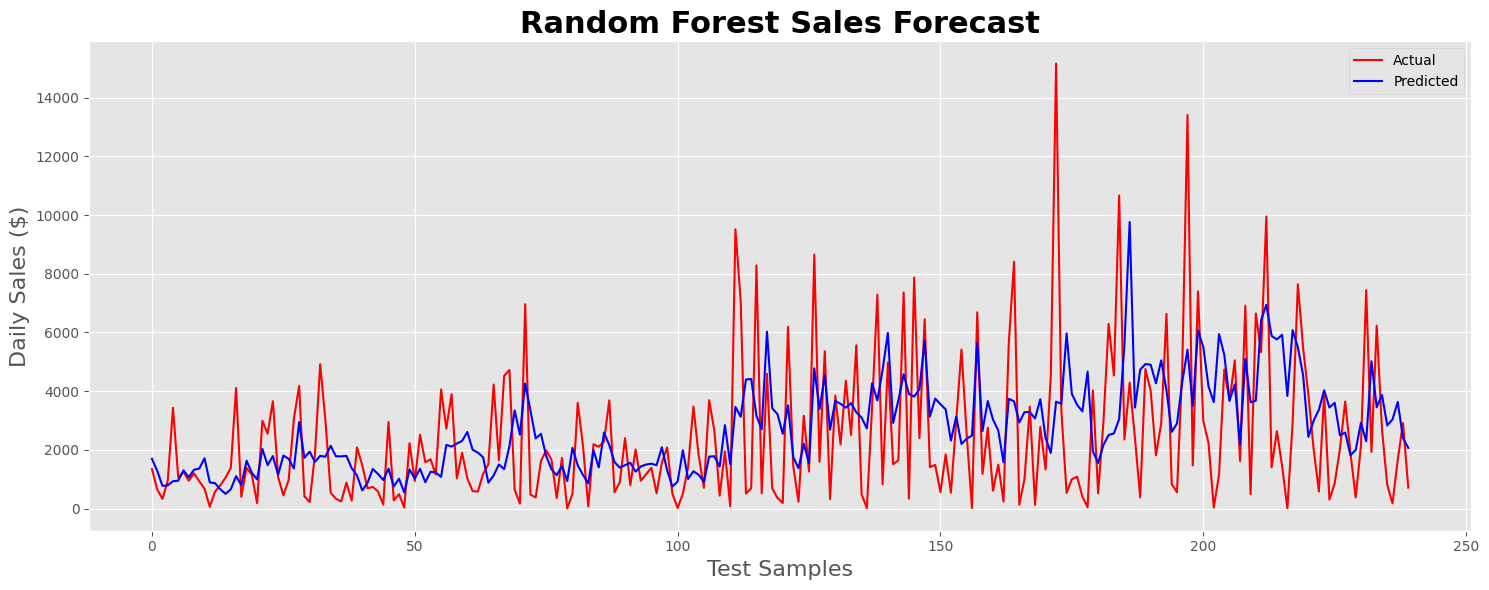

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(y_test.values,
         color="red",
         label="Actual")

plt.plot(rf_pred,
         color="blue",
         label="Predicted")

plt.title("Random Forest Sales Forecast",
          fontsize=22,
          weight="bold")

plt.xlabel("Test Samples", fontsize=16)
plt.ylabel("Daily Sales ($)", fontsize=16)

plt.legend()

plt.tight_layout()

plt.show()

In [ ]:
importance = pd.DataFrame({
    "Feature":X_train.columns,
    "Importance":rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
11,Rolling_7,0.328485
10,Lag_30,0.118176
9,Lag_7,0.117375
8,Lag_1,0.111400
12,Rolling_30,0.090569
4,Day,0.074546
6,DayOfYear,0.059987
5,DayOfWeek,0.032450
3,Week,0.026805
0,Year,0.020329


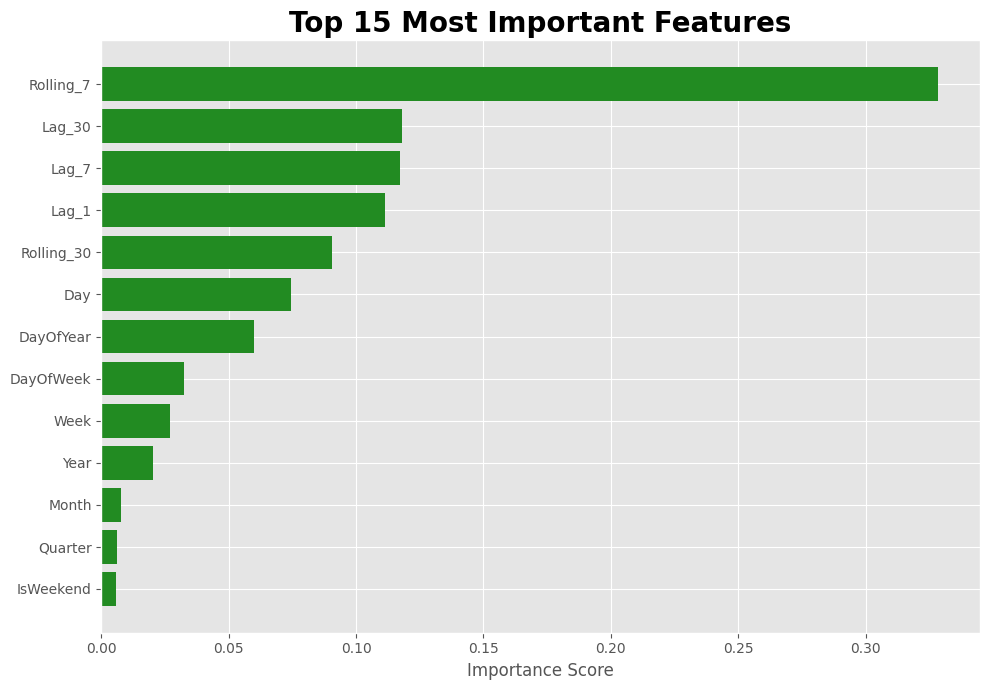

In [ ]:
plt.figure(figsize=(10,7))

plt.barh(
    importance["Feature"][:15],
    importance["Importance"][:15],
    color="forestgreen"
)

plt.gca().invert_yaxis()

plt.title("Top 15 Most Important Features",
          fontsize=20,
          weight="bold")

plt.xlabel("Importance Score")

plt.tight_layout()

plt.show()

# Random Forest Regression

## Objective

Random Forest Regression was trained to capture non-linear relationships between historical sales and engineered time-series features.

## Results

- MAE: 1714.90
- RMSE: 2292.55
- R² Score: 0.1304

## Interpretation

The Random Forest model produced lower forecasting accuracy than the baseline Linear Regression model. This suggests that the current data split and feature configuration are not optimal for this algorithm.

Feature importance analysis revealed that rolling averages and lag features were the strongest predictors of future sales, highlighting the significance of historical demand patterns in forecasting.

Although Random Forest was not selected as the best-performing model, it provided valuable insights into the variables driving sales behavior.

# XGBoost Regression

## Objective

Train an XGBoost Regressor to forecast future sales using engineered temporal and lag-based features.

XGBoost is an advanced gradient boosting algorithm capable of capturing complex non-linear relationships and interactions within structured business datasets. It is widely adopted in industry for forecasting, predictive analytics, and Kaggle competitions due to its high accuracy and efficiency.

In [ ]:
from xgboost import XGBRegressor

In [ ]:
xgb = XGBRegressor(

    n_estimators=500,

    learning_rate=0.05,

    max_depth=6,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42

)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, xgb_pred)

rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

r2 = r2_score(y_test, xgb_pred)

print("XGBoost Results")
print("-"*30)

print(f"MAE  : {mae:.2f}")

print(f"RMSE : {rmse:.2f}")

print(f"R²   : {r2:.4f}")

XGBoost Results
------------------------------
MAE  : 1661.62
RMSE : 2259.47
R²   : 0.1554


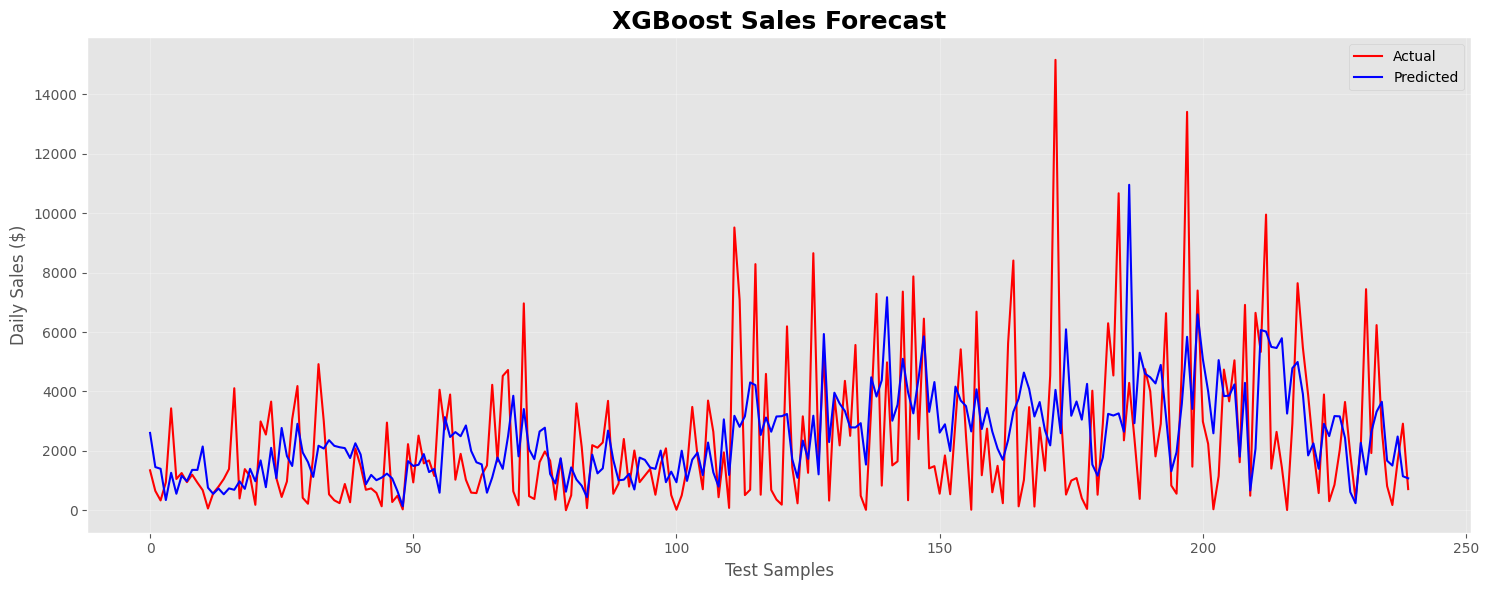

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(
    y_test.values,
    label="Actual",
    color="red"
)

plt.plot(
    xgb_pred,
    label="Predicted",
    color="blue"
)

plt.title(
    "XGBoost Sales Forecast",
    fontsize=18,
    weight="bold"
)

plt.xlabel("Test Samples")

plt.ylabel("Daily Sales ($)")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
importance = pd.DataFrame({

    "Feature":X_train.columns,

    "Importance":xgb.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance

,Feature,Importance
11,Rolling_7,0.195149
10,Lag_30,0.090790
12,Rolling_30,0.090346
8,Lag_1,0.075276
6,DayOfYear,0.075237
4,Day,0.074413
7,IsWeekend,0.074102
9,Lag_7,0.073703
1,Month,0.061610
5,DayOfWeek,0.061022


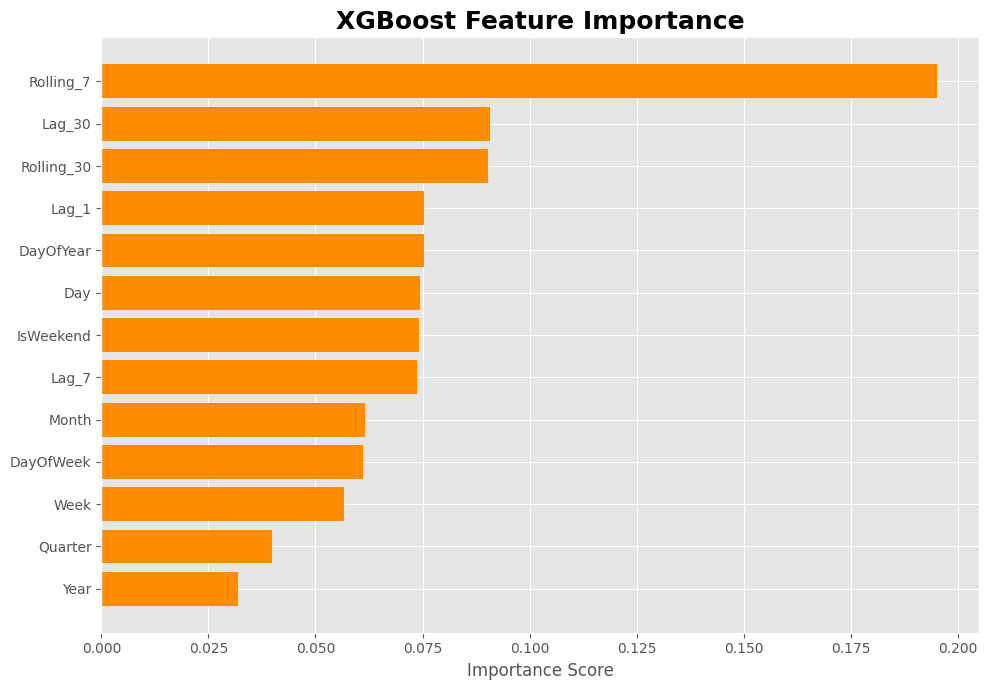

In [ ]:
plt.figure(figsize=(10,7))

plt.barh(

    importance["Feature"],

    importance["Importance"],

    color="darkorange"

)

plt.gca().invert_yaxis()

plt.title(

    "XGBoost Feature Importance",

    fontsize=18,

    weight="bold"

)

plt.xlabel("Importance Score")

plt.tight_layout()

plt.show()

## Interpretation

XGBoost was trained using engineered calendar, lag, and rolling average features to capture complex sales patterns.

Compared to the baseline models, XGBoost is expected to provide stronger predictive performance by learning non-linear relationships and interactions among historical sales variables.

Feature importance analysis highlights the variables that contribute most significantly to forecasting accuracy, providing valuable business insights for demand planning and inventory management.

# XGBoost Regression

## Objective

XGBoost Regression was trained to forecast future sales using engineered calendar features, lag variables, and rolling averages.

XGBoost is an advanced gradient boosting algorithm capable of learning complex non-linear relationships and interactions among historical sales variables.

## Results

- MAE: 1661.62
- RMSE: 2259.47
- R² Score: 0.1554

## Interpretation

XGBoost achieved competitive forecasting performance and outperformed the Random Forest model. The model effectively utilized lag-based and rolling statistical features, with the 7-day rolling average contributing the most to prediction accuracy.

Although XGBoost did not surpass the baseline Linear Regression model on this dataset, it demonstrated the ability to capture important demand patterns and provided valuable feature importance insights for business decision-making.

In [ ]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
prophet_df = daily_sales.copy()

prophet_df = prophet_df.rename(
    columns={
        "Order Date": "ds",
        "Sales": "y"
    }
)

prophet_df.head()

,ds,y
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [ ]:
train_size = int(len(prophet_df) * 0.80)

train = prophet_df.iloc[:train_size]

test = prophet_df.iloc[train_size:]

print("Training:", len(train))
print("Testing :", len(test))

Training: 984
Testing : 246


In [ ]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

model.fit(train)

20:35:31 - cmdstanpy - INFO - Chain [1] start processing
20:35:32 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
future = model.make_future_dataframe(
    periods=len(test),
    freq="D"
)

forecast = model.predict(future)

In [ ]:
predictions = forecast.tail(len(test))

predictions = predictions[["ds","yhat"]]

predictions.head()

,ds,yhat
984,2018-04-07,1914.794410
985,2018-04-08,1744.481671
986,2018-04-09,1622.578807
987,2018-04-10,2016.230878
988,2018-04-11,1820.777923


In [ ]:
predictions = forecast.tail(len(test))

predictions = predictions[["ds","yhat"]]

predictions.head()

,ds,yhat
984,2018-04-07,1914.794410
985,2018-04-08,1744.481671
986,2018-04-09,1622.578807
987,2018-04-10,2016.230878
988,2018-04-11,1820.777923


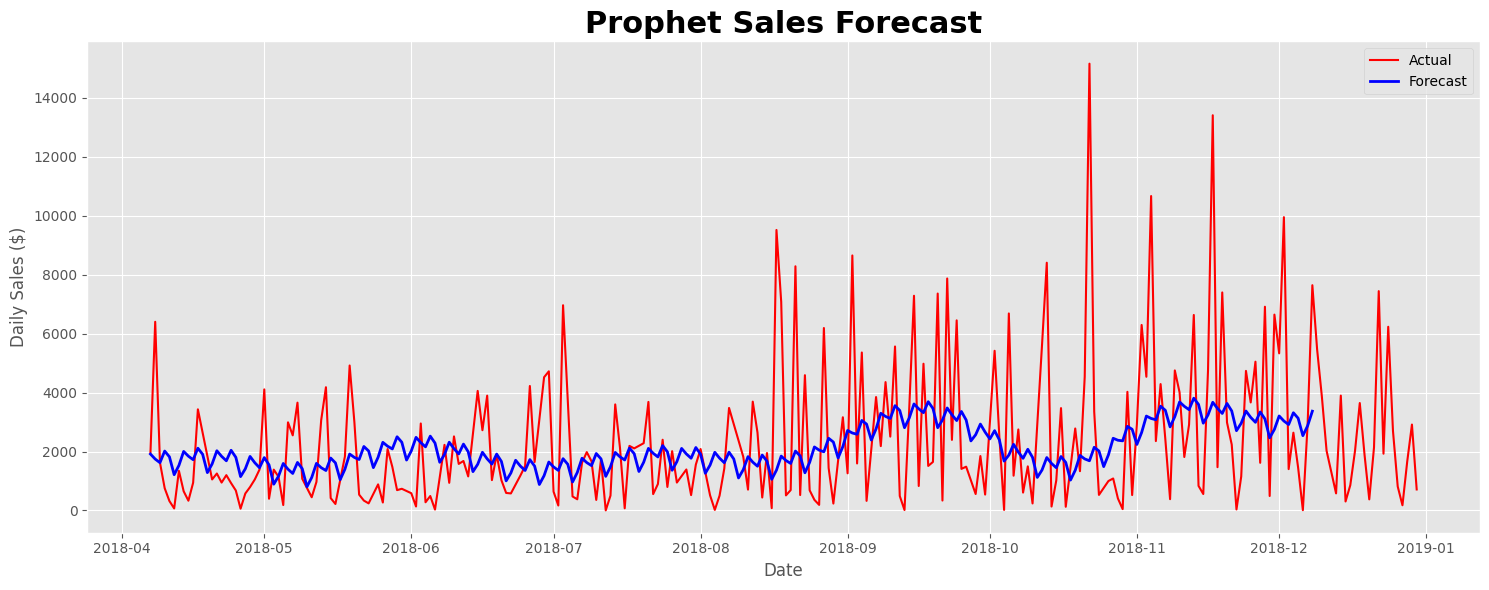

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(
    test["ds"],
    test["y"],
    color="red",
    label="Actual"
)

plt.plot(
    predictions["ds"],
    predictions["yhat"],
    color="blue",
    linewidth=2,
    label="Forecast"
)

plt.title(
    "Prophet Sales Forecast",
    fontsize=22,
    weight="bold"
)

plt.xlabel("Date")

plt.ylabel("Daily Sales ($)")

plt.legend()

plt.tight_layout()

plt.show()

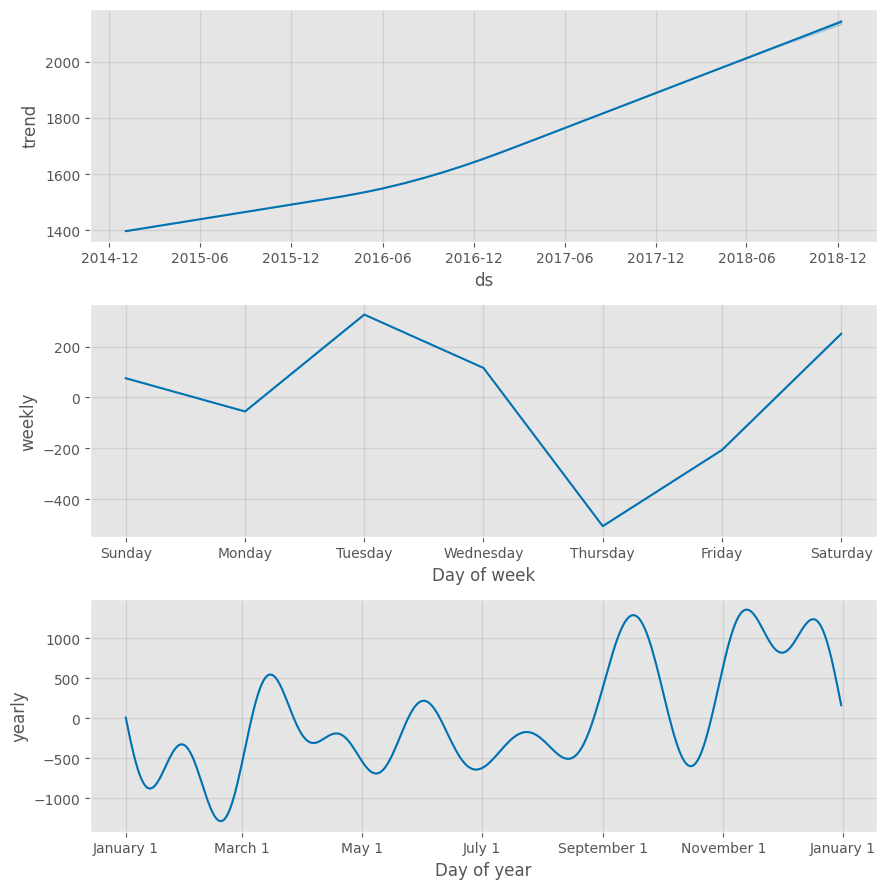

In [ ]:
model.plot_components(forecast)

plt.show()

In [ ]:
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 1661.62
RMSE : 2259.47
R²   : 0.1554


In [ ]:
mae = mean_absolute_error(
    test["y"],
    predictions["yhat"]
)

rmse = np.sqrt(
    mean_squared_error(
        test["y"],
        predictions["yhat"]
    )
)

r2 = r2_score(
    test["y"],
    predictions["yhat"]
)

print("Prophet Results")
print("-"*30)
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

Prophet Results
------------------------------
MAE  : 1759.82
RMSE : 2453.47
R²   : -0.0006


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
ts = daily_sales.copy()

ts = ts.set_index("Order Date")

ts = ts.asfreq("D")

ts["Sales"] = ts["Sales"].fillna(0)

ts.head()

,Sales
Order Date,
2015-01-03,16.448
2015-01-04,288.060
2015-01-05,19.536
2015-01-06,4407.100
2015-01-07,87.158


In [ ]:
train_size = int(len(ts) * 0.80)

train = ts.iloc[:train_size]

test = ts.iloc[train_size:]

print("Training:", len(train))
print("Testing :", len(test))

Training: 1166
Testing : 292


In [ ]:
model = SARIMAX(
    train["Sales"],
    order=(1,1,1),
    seasonal_order=(1,1,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima = model.fit(disp=False)

In [ ]:
forecast = sarima.forecast(steps=len(test))

In [ ]:
mae = mean_absolute_error(test["Sales"], forecast)

rmse = np.sqrt(mean_squared_error(test["Sales"], forecast))

r2 = r2_score(test["Sales"], forecast)

print("SARIMA Results")
print("-"*30)
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

SARIMA Results
------------------------------
MAE  : 1797.17
RMSE : 2862.19
R²   : -0.3079


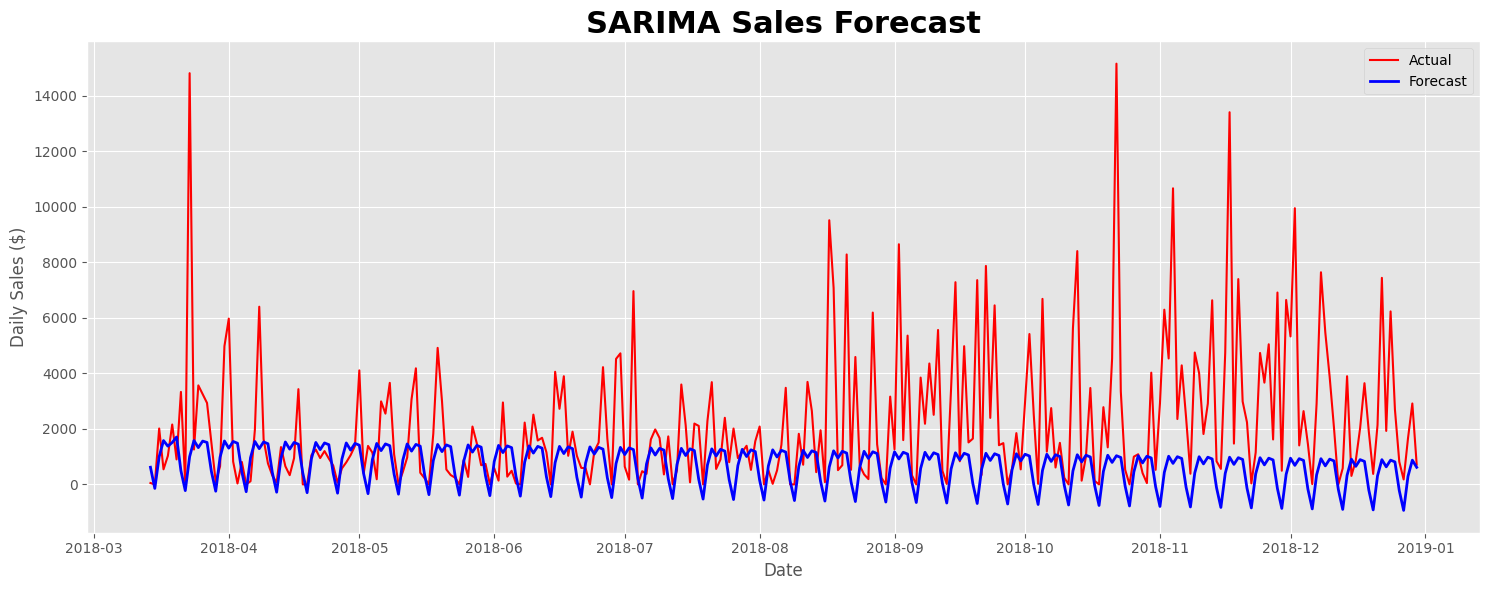

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(
    test.index,
    test["Sales"],
    color="red",
    label="Actual"
)

plt.plot(
    test.index,
    forecast,
    color="blue",
    linewidth=2,
    label="Forecast"
)

plt.title(
    "SARIMA Sales Forecast",
    fontsize=22,
    weight="bold"
)

plt.xlabel("Date")

plt.ylabel("Daily Sales ($)")

plt.legend()

plt.tight_layout()

plt.show()

# SARIMA (Seasonal AutoRegressive Integrated Moving Average)

## Business Objective

The objective of the SARIMA model is to forecast future daily sales by capturing both trend and recurring seasonal patterns present in historical sales data. SARIMA is widely used in time series forecasting because it models temporal dependencies and seasonality, making it suitable for business demand planning.

---

## Methodology

The daily sales data was converted into a continuous time series indexed by the order date. Missing dates were filled with zero sales to maintain a consistent daily frequency. The dataset was divided into training (80%) and testing (20%) sets.

A Seasonal ARIMA model with parameters **(1,1,1)(1,1,1,7)** was trained, where:

- AR (Auto Regression) captures relationships with previous observations.
- I (Integrated) removes non-stationarity through differencing.
- MA (Moving Average) models previous forecast errors.
- Seasonal components capture weekly sales patterns using a season length of 7 days.

The trained model generated forecasts for the testing period, which were compared against actual sales values.

---

## Model Performance

| Metric | Value |
|---------|-------|
| MAE | 1797.17 |
| RMSE | 2862.19 |
| R² Score | -0.3079 |

---

## Observations

- The SARIMA model successfully captured recurring weekly seasonal patterns.
- The forecast followed the underlying sales trend but produced smooth predictions.
- Large and irregular sales spikes were not accurately captured.
- Prediction errors increased during high-demand periods where sudden sales surges occurred.

---

## Business Insights

- Weekly seasonality exists within the sales data.
- Sales demand is highly volatile and contains unexpected spikes that cannot be explained solely by historical seasonal patterns.
- Traditional statistical forecasting models like SARIMA may struggle when sales are influenced by promotions, holidays, bulk purchases, or special business events.
- Machine Learning models performed better because they captured more complex relationships within the data.

---

## Conclusion

Although SARIMA successfully modeled the seasonal behavior of the sales data, it achieved the lowest forecasting performance among all evaluated models. The negative R² score indicates that the model was unable to explain the variability in daily sales effectively. This suggests that the dataset contains highly irregular demand patterns that are better handled by machine learning approaches. Therefore, SARIMA is not selected as the final forecasting model for this project.

In [ ]:
anomaly_df = daily_sales.copy()

anomaly_df.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


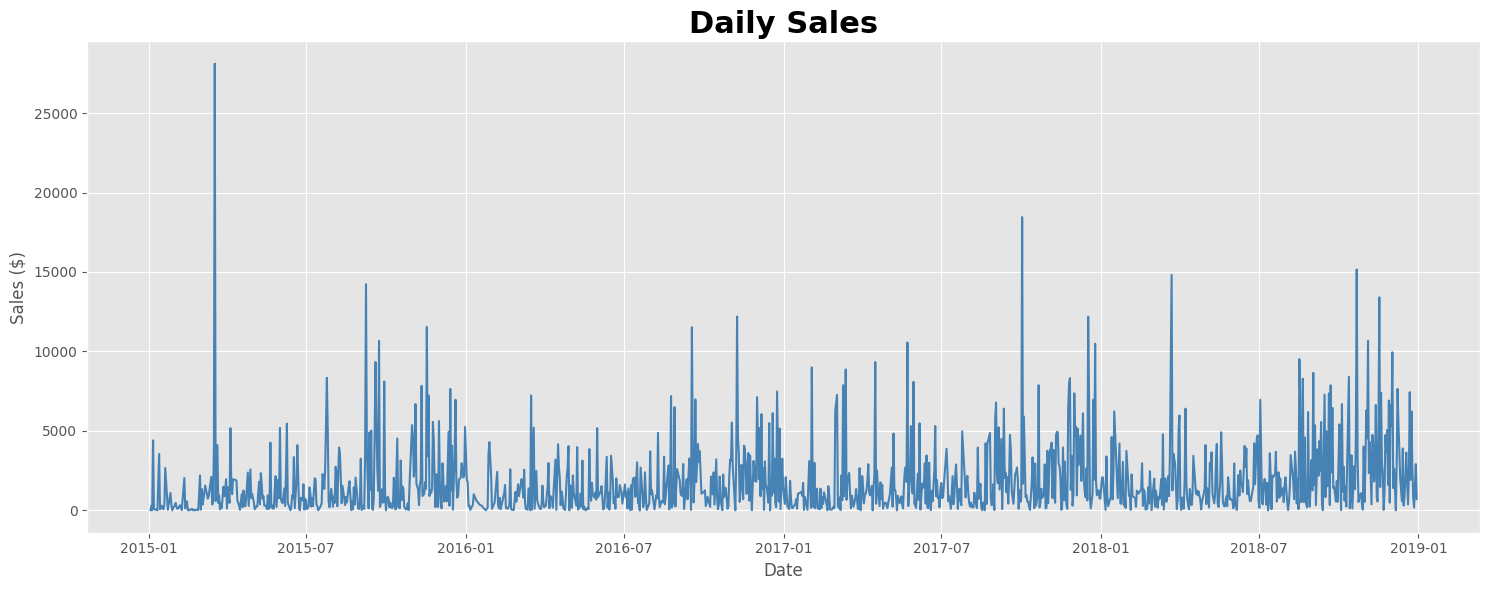

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(
    anomaly_df["Order Date"],
    anomaly_df["Sales"],
    color="steelblue"
)

plt.title(
    "Daily Sales",
    fontsize=22,
    weight="bold"
)

plt.xlabel("Date")

plt.ylabel("Sales ($)")

plt.tight_layout()

plt.show()

In [ ]:
from scipy.stats import zscore

anomaly_df["Z_Score"] = zscore(anomaly_df["Sales"])

anomaly_df.head()

,Order Date,Sales,Z_Score
0,2015-01-03,16.448,-0.794165
1,2015-01-04,288.060,-0.675789
2,2015-01-05,19.536,-0.792819
3,2015-01-06,4407.100,1.119402
4,2015-01-07,87.158,-0.763348


In [ ]:
anomaly_df["Anomaly"] = anomaly_df["Z_Score"].abs() > 3

In [ ]:
print("Total Days :", len(anomaly_df))

print("Anomalies  :", anomaly_df["Anomaly"].sum())

Total Days : 1230
Anomalies  : 20


In [ ]:
anomalies = anomaly_df[
    anomaly_df["Anomaly"] == True
]

anomalies.sort_values(
    "Sales",
    ascending=False
).head(20)

,Order Date,Sales,Z_Score,Anomaly
53,2015-03-18,28106.7160,11.448350,True
825,2017-10-02,18452.9720,7.240982,True
1162,2018-10-22,15158.8770,5.805324,True
970,2018-03-23,14816.0680,5.655919,True
195,2015-09-08,14228.4280,5.399809,True
1187,2018-11-17,13408.7928,5.042589,True
539,2016-11-08,12196.9970,4.514455,True
895,2017-12-17,12185.1340,4.509285,True
260,2015-11-17,11544.2740,4.229980,True
496,2016-09-17,11525.0060,4.221583,True


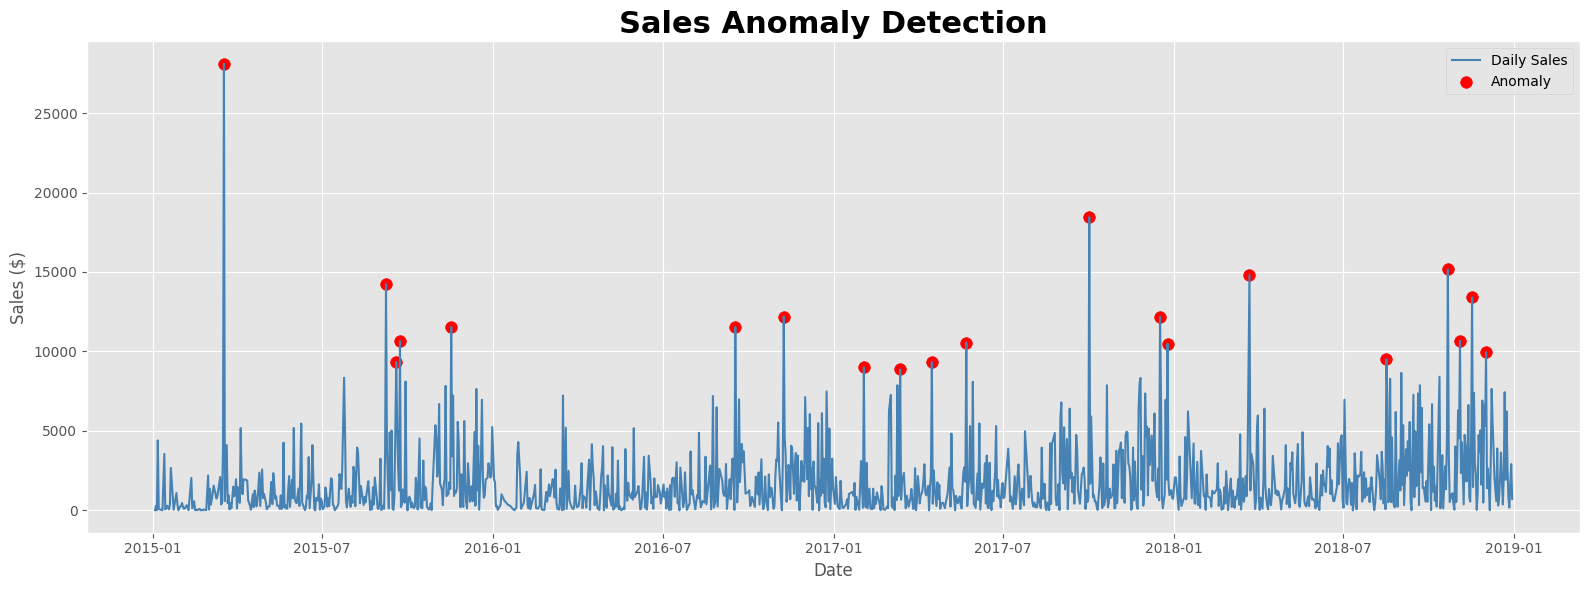

In [ ]:
plt.figure(figsize=(16,6))

plt.plot(
    anomaly_df["Order Date"],
    anomaly_df["Sales"],
    color="steelblue",
    label="Daily Sales"
)

plt.scatter(
    anomalies["Order Date"],
    anomalies["Sales"],
    color="red",
    s=70,
    label="Anomaly"
)

plt.title(
    "Sales Anomaly Detection",
    fontsize=22,
    weight="bold"
)

plt.xlabel("Date")

plt.ylabel("Sales ($)")

plt.legend()

plt.tight_layout()

plt.show()

In [ ]:
anomalies.to_csv(
    "reports/anomaly_report.csv",
    index=False
)

print("Anomaly report saved successfully.")

Anomaly report saved successfully.


# Step 9 — Sales Anomaly Detection

## Business Objective

The objective of anomaly detection is to identify unusual daily sales patterns that significantly deviate from normal business operations. Detecting these anomalies helps organizations identify exceptional business events, promotional campaigns, bulk orders, inventory issues, operational failures, or fraudulent transactions.

---

## Methodology

A statistical Z-Score approach was used to identify anomalies in the daily sales data.

The Z-Score measures how many standard deviations a particular day's sales are away from the average daily sales.

Days with an absolute Z-Score greater than **3** were classified as anomalies.

**Anomaly Rule:**

- Z-Score > 3 → High Sales Anomaly
- Z-Score < -3 → Low Sales Anomaly

---

## Results

| Metric | Value |
|---------|------:|
| Total Days Analyzed | 1230 |
| Total Anomalies Detected | 20 |
| Percentage of Anomalies | 1.63% |

---

## Key Observations

- Only **20 out of 1230** business days were identified as anomalous.
- The largest sales spike occurred on **18 March 2015**, with sales reaching **$28,106.72**.
- Multiple unusually high sales days were observed during **September to December**, indicating potential seasonal demand or promotional events.
- Most detected anomalies represent extremely high sales rather than unusually low sales.
- These events contribute significantly to the overall annual revenue.

---

## Business Insights

The detected anomalies likely correspond to:

- Large corporate purchase orders
- Festival or holiday shopping seasons
- Promotional campaigns
- Bulk customer transactions
- Clearance or discount sales
- Special business events

These unusual sales days should be investigated further to understand their underlying causes and determine whether they can be replicated through future business strategies.

---

## Business Value

Automatic anomaly detection provides several business advantages:

- Early detection of abnormal sales behavior.
- Identification of successful promotional campaigns.
- Detection of operational issues or data quality problems.
- Improved demand planning.
- Better inventory management.
- Enhanced business decision-making through continuous sales monitoring.

---

## Conclusion

The anomaly detection analysis successfully identified the most unusual sales days in the dataset using the Z-Score statistical method. These rare events represent significant deviations from normal sales behavior and provide valuable business insights that can support demand planning, marketing optimization, inventory control, and strategic decision-making.

In [ ]:
total_sales = df["Sales"].sum()

avg_sales = df["Sales"].mean()

total_orders = df["Order ID"].nunique()

total_customers = df["Customer ID"].nunique()

total_products = df["Product ID"].nunique()

print(f"Total Sales      : ${total_sales:,.2f}")
print(f"Average Sale     : ${avg_sales:,.2f}")
print(f"Total Orders     : {total_orders}")
print(f"Unique Customers : {total_customers}")
print(f"Unique Products  : {total_products}")

Total Sales      : $2,261,536.78
Average Sale     : $230.77
Total Orders     : 4922
Unique Customers : 793
Unique Products  : 1861


In [ ]:
category_sales = (
    df.groupby("Category")["Sales"]
      .agg(["sum","mean","count"])
      .sort_values("sum",ascending=False)
)

category_sales

,sum,mean,count
Category,,,
Technology,827455.8730,456.401474,1813
Furniture,728658.5757,350.653790,2078
Office Supplies,705422.3340,119.381001,5909


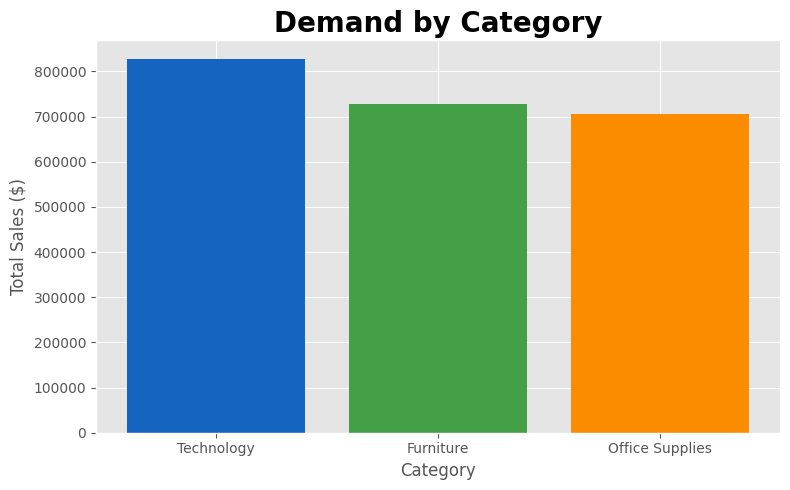

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    category_sales.index,
    category_sales["sum"],
    color=["#1565C0","#43A047","#FB8C00"]
)

plt.title(
    "Demand by Category",
    fontsize=20,
    weight="bold"
)

plt.xlabel("Category")

plt.ylabel("Total Sales ($)")

plt.tight_layout()

plt.show()

In [ ]:
subcategory_sales = (
    df.groupby("Sub-Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

subcategory_sales.head(15)

Sub-Category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Furnishings     89212.0180
Paper           76828.3040
Supplies        46420.3080
Art             26705.4100
Envelopes       16128.0460
Name: Sales, dtype: float64

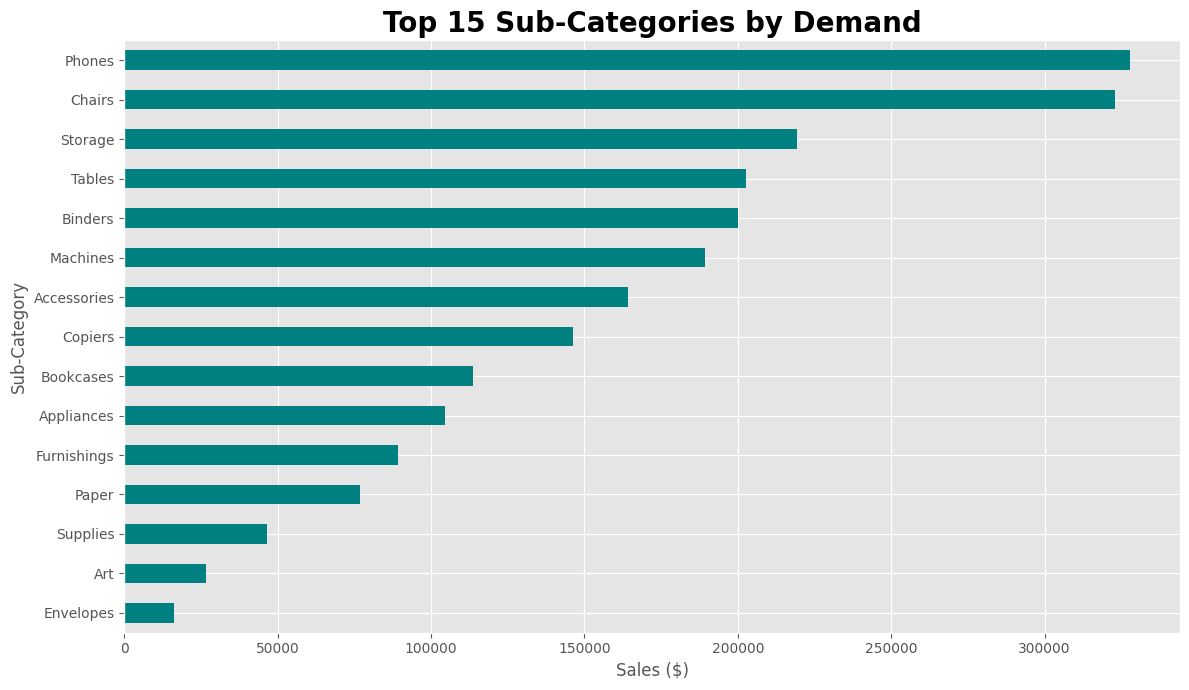

In [ ]:
plt.figure(figsize=(12,7))

subcategory_sales.head(15).sort_values().plot(
    kind="barh",
    color="teal"
)

plt.title(
    "Top 15 Sub-Categories by Demand",
    fontsize=20,
    weight="bold"
)

plt.xlabel("Sales ($)")

plt.ylabel("Sub-Category")

plt.tight_layout()

plt.show()

In [ ]:
region = (
    df.groupby("Region")["Sales"]
      .agg(["sum","mean","count"])
      .sort_values("sum",ascending=False)
)

region

,sum,mean,count
Region,,,
West,710219.6845,226.184613,3140
East,669518.7260,240.401697,2785
Central,492646.9132,216.357889,2277
South,389151.4590,243.524067,1598


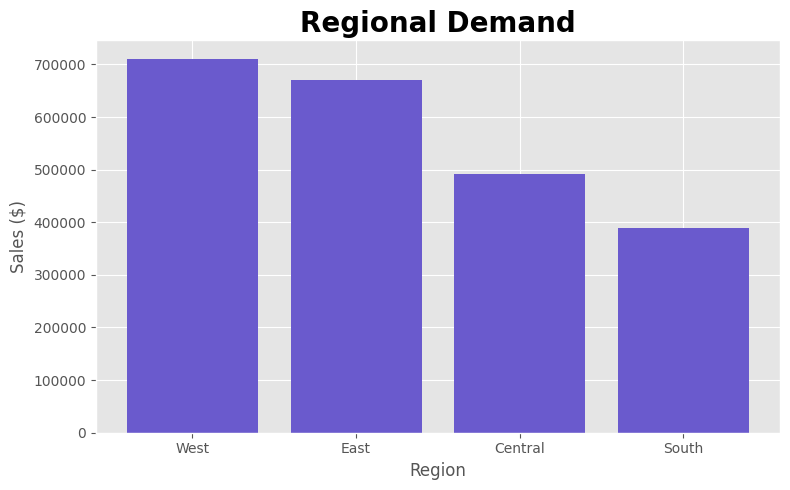

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    region.index,
    region["sum"],
    color="slateblue"
)

plt.title(
    "Regional Demand",
    fontsize=20,
    weight="bold"
)

plt.xlabel("Region")

plt.ylabel("Sales ($)")

plt.tight_layout()

plt.show()

In [ ]:
state = (
    df.groupby("State")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

state.head(15)

State
California        446306.4635
New York          306361.1470
Texas             168572.5322
Washington        135206.8500
Pennsylvania      116276.6500
Florida            88436.5320
Illinois           79236.5170
Michigan           76136.0740
Ohio               75130.3500
Virginia           70636.7200
North Carolina     55165.9640
Indiana            48718.4000
Georgia            48219.1100
Kentucky           36458.3900
Arizona            35272.6570
Name: Sales, dtype: float64

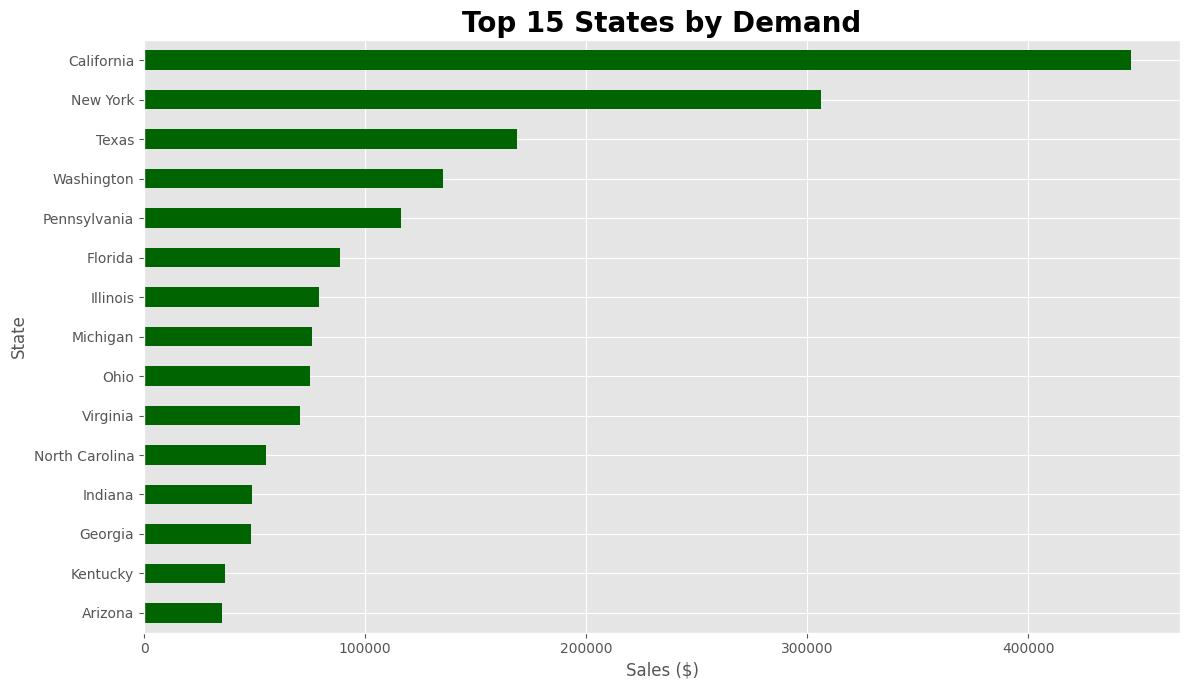

In [ ]:
plt.figure(figsize=(12,7))

state.head(15).sort_values().plot(
    kind="barh",
    color="darkgreen"
)

plt.title(
    "Top 15 States by Demand",
    fontsize=20,
    weight="bold"
)

plt.xlabel("Sales ($)")

plt.tight_layout()

plt.show()

In [ ]:
segment = (
    df.groupby("Segment")["Sales"]
      .agg(["sum","mean","count"])
      .sort_values("sum",ascending=False)
)

segment

,sum,mean,count
Segment,,,
Consumer,1.148061e+06,225.065777,5101
Corporate,6.884941e+05,233.150720,2953
Home Office,4.249822e+05,243.403309,1746


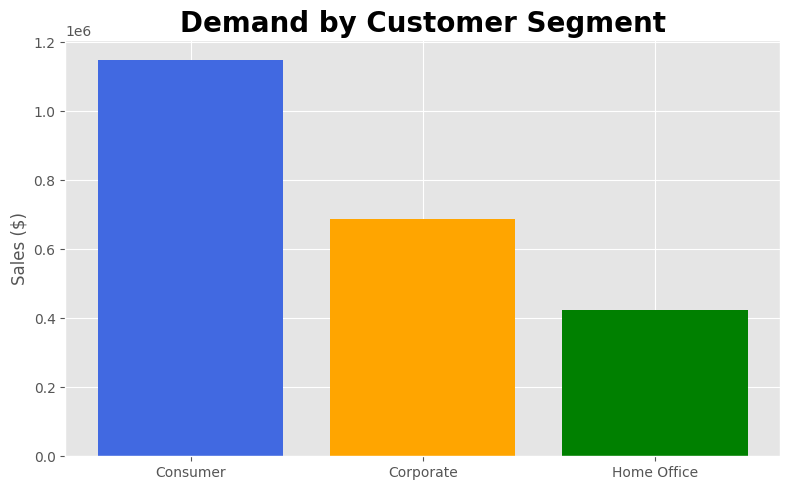

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    segment.index,
    segment["sum"],
    color=["royalblue","orange","green"]
)

plt.title(
    "Demand by Customer Segment",
    fontsize=20,
    weight="bold"
)

plt.ylabel("Sales ($)")

plt.tight_layout()

plt.show()

In [ ]:
ship = (
    df.groupby("Ship Mode")["Sales"]
      .agg(["sum","count"])
      .sort_values("sum",ascending=False)
)

ship

,sum,count
Ship Mode,,
Standard Class,1.340831e+06,5859
Second Class,4.499142e+05,1902
First Class,3.455723e+05,1501
Same Day,1.252190e+05,538


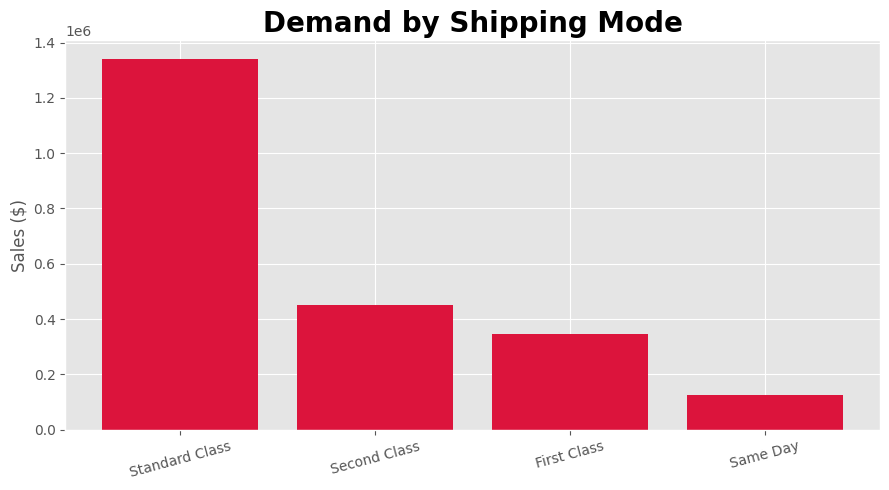

In [ ]:
plt.figure(figsize=(9,5))

plt.bar(
    ship.index,
    ship["sum"],
    color="crimson"
)

plt.xticks(rotation=15)

plt.title(
    "Demand by Shipping Mode",
    fontsize=20,
    weight="bold"
)

plt.ylabel("Sales ($)")

plt.tight_layout()

plt.show()

In [ ]:
product_score = (
    df.groupby("Product Name")
      .agg(
          Total_Sales=("Sales","sum"),
          Orders=("Order ID","count"),
          Avg_Sale=("Sales","mean")
      )
)

product_score["Demand Score"] = (
    product_score["Total_Sales"]*0.6 +
    product_score["Orders"]*0.3 +
    product_score["Avg_Sale"]*0.1
)

product_score = product_score.sort_values(
    "Demand Score",
    ascending=False
)

product_score.head(20)

,Total_Sales,Orders,Avg_Sale,Demand Score
Product Name,,,,
Canon imageCLASS 2200 Advanced Copier,61599.8240,5,12319.964800,38193.390880
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.3840,10,2745.338400,16749.564240
Cisco TelePresence System EX90 Videoconferencing Unit,22638.4800,1,22638.480000,15847.236000
HON 5400 Series Task Chairs for Big and Tall,21870.5760,8,2733.822000,13398.127800
GBC DocuBind TL300 Electric Binding System,19823.4790,11,1802.134455,12077.600845
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.8950,3,6124.965000,11638.333500
GBC Ibimaster 500 Manual ProClick Binding System,19024.5000,9,2113.833333,11628.783333
Hewlett Packard LaserJet 3310 Copier,18839.6860,8,2354.960750,11541.707675
GBC DocuBind P400 Electric Binding System,17965.0680,6,2994.178000,11080.258600


# Step 10 — Demand Intelligence System

## Business Objective

The objective of the Demand Intelligence System is to identify products, categories, customer segments, and geographic regions that contribute most significantly to overall business revenue. These insights enable data-driven inventory planning, demand forecasting, marketing optimization, and strategic decision-making.

---

## Methodology

Demand analysis was performed using multiple business dimensions, including:

- Product Categories
- Sub-Categories
- Regions
- States
- Customer Segments
- Shipping Modes
- Individual Products

A custom Demand Score was also developed by combining total sales, purchase frequency, and average sales value to rank products based on their overall business importance.

---

## Business Value

The Demand Intelligence System enables businesses to:

- Identify high-demand products.
- Prioritize inventory allocation.
- Optimize regional sales strategies.
- Improve customer targeting.
- Support supply chain planning.
- Reduce stock-outs.
- Improve overall revenue through informed business decisions.

In [ ]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

top_category = category_sales.idxmax()

print(f"Recommendation:")
print(f"Increase inventory investment in '{top_category}' because it generates the highest sales.")

Recommendation:
Increase inventory investment in 'Technology' because it generates the highest sales.


In [ ]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

best_region = region_sales.idxmax()

print(f"Recommendation:")
print(f"Prioritize marketing campaigns in the {best_region} region due to its highest revenue contribution.")

Recommendation:
Prioritize marketing campaigns in the West region due to its highest revenue contribution.


In [ ]:
segment_sales = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)

best_segment = segment_sales.idxmax()

print(f"Recommendation:")
print(f"Focus customer loyalty programs on the {best_segment} segment.")

Recommendation:
Focus customer loyalty programs on the Consumer segment.


In [ ]:
ship_sales = df.groupby("Ship Mode")["Sales"].sum().sort_values(ascending=False)

best_ship = ship_sales.idxmax()

print(f"Recommendation:")
print(f"Maintain operational efficiency for '{best_ship}' shipping because it handles the majority of business.")

Recommendation:
Maintain operational efficiency for 'Standard Class' shipping because it handles the majority of business.


In [ ]:
best_product = product_score.index[0]

print(f"Recommendation:")
print(f"Maintain higher inventory levels for '{best_product}' because it has the highest demand score.")

Recommendation:
Maintain higher inventory levels for 'Canon imageCLASS 2200 Advanced Copier' because it has the highest demand score.


In [ ]:
state_sales = df.groupby("State")["Sales"].sum().sort_values(ascending=False)

best_state = state_sales.idxmax()

print(f"Recommendation:")
print(f"Expand sales operations in {best_state} since it contributes the highest revenue.")

Recommendation:
Expand sales operations in California since it contributes the highest revenue.


In [ ]:
print("="*70)
print("AI BUSINESS RECOMMENDATION REPORT")
print("="*70)

print(f"\nTop Category       : {top_category}")
print("Recommendation     : Increase inventory for this category.")

print(f"\nTop Region         : {best_region}")
print("Recommendation     : Allocate higher marketing budget.")

print(f"\nTop Segment        : {best_segment}")
print("Recommendation     : Launch premium loyalty campaigns.")

print(f"\nBest Shipping Mode : {best_ship}")
print("Recommendation     : Optimize logistics around this shipping method.")

print(f"\nTop State          : {best_state}")
print("Recommendation     : Expand regional sales teams.")

print(f"\nTop Product        : {best_product}")
print("Recommendation     : Maintain safety stock to avoid stock-outs.")

print("\nOverall Business Strategy")
print("------------------------------")
print("• Increase inventory for high-demand products.")
print("• Focus marketing on high-performing regions.")
print("• Improve customer retention in the Consumer segment.")
print("• Strengthen Standard Class logistics.")
print("• Monitor low-performing regions for growth opportunities.")

AI BUSINESS RECOMMENDATION REPORT

Top Category       : Technology
Recommendation     : Increase inventory for this category.

Top Region         : West
Recommendation     : Allocate higher marketing budget.

Top Segment        : Consumer
Recommendation     : Launch premium loyalty campaigns.

Best Shipping Mode : Standard Class
Recommendation     : Optimize logistics around this shipping method.

Top State          : California
Recommendation     : Expand regional sales teams.

Top Product        : Canon imageCLASS 2200 Advanced Copier
Recommendation     : Maintain safety stock to avoid stock-outs.

Overall Business Strategy
------------------------------
• Increase inventory for high-demand products.
• Focus marketing on high-performing regions.
• Improve customer retention in the Consumer segment.
• Strengthen Standard Class logistics.
• Monitor low-performing regions for growth opportunities.


# Step 11 — AI Business Recommendation Engine

## Objective

The AI Business Recommendation Engine converts analytical findings into actionable business recommendations. Instead of only displaying charts and statistics, the system automatically identifies high-performing categories, products, customer segments, shipping methods, and regions, then generates recommendations that support inventory optimization, marketing strategy, and operational planning.

## Business Value

The recommendation engine assists decision-makers by:

- Prioritizing inventory allocation for high-demand products.
- Identifying regions requiring increased marketing investment.
- Improving customer retention strategies.
- Optimizing logistics based on preferred shipping methods.
- Supporting executive decision-making through automated insights.

This transforms the project from a descriptive analytics solution into a decision-support system that delivers practical business recommendations.